

---
## Importing Data, checking for data consistency and distribution


---



In [1]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yfin
from datetime import date

pd.options.display.float_format="{:,.6f}".format

In [2]:
import requests

url = "https://ngxpulse.ng/api/ngxdata/stocks"
headers = {
    "x-api-key": "ngxpulse_lzk9tcf9ok1beonm"
}

response = requests.get(url, headers=headers)
print(response.json())

{'stocks': [{'symbol': 'MTNN', 'name': 'MTN Nigeria Communications Plc', 'current_price': 760, 'previous_close': 760, 'change_percent': None, 'pct_change_7d': 0.26, 'volume': 2099579, 'market_cap': 15956625678280, 'shares_outstanding': 20995560103, 'sector': 'ICT', 'market': 'Premium Board', 'trade_date': '2026-04-02T00:00:00'}, {'symbol': 'BUAFOODS', 'name': 'BUA Foods Plc', 'current_price': 798, 'previous_close': 798, 'change_percent': None, 'pct_change_7d': 0, 'volume': 49751, 'market_cap': 14364000000000, 'shares_outstanding': 18000000000, 'sector': 'CONSUMER GOODS', 'market': 'Main Board', 'trade_date': '2026-04-02T00:00:00'}, {'symbol': 'DANGCEM', 'name': 'Dangote Cement Plc', 'current_price': 810, 'previous_close': 810, 'change_percent': None, 'pct_change_7d': 0, 'volume': 305860, 'market_cap': 13667582993310, 'shares_outstanding': 16873559251, 'sector': 'INDUSTRIAL GOODS', 'market': 'Premium Board', 'trade_date': '2026-04-02T00:00:00'}, {'symbol': 'BUACEMENT', 'name': 'BUA Ceme

In [3]:
stock_data = response.json()
df_stock = pd.DataFrame(stock_data['stocks'])
df_stock.head(10)

,symbol,name,current_price,previous_close,change_percent,pct_change_7d,volume,market_cap,shares_outstanding,sector,market,trade_date
0,MTNN,MTN Nigeria Communications Plc,760.000000,760.000000,NaN,0.260000,"2,099,579.000000","15,956,625,678,280.000000",20995560103,ICT,Premium Board,2026-04-02T00:00:00
1,BUAFOODS,BUA Foods Plc,798.000000,798.000000,NaN,0.000000,"49,751.000000","14,364,000,000,000.000000",18000000000,CONSUMER GOODS,Main Board,2026-04-02T00:00:00
2,DANGCEM,Dangote Cement Plc,810.000000,810.000000,NaN,0.000000,"305,860.000000","13,667,582,993,310.000000",16873559251,INDUSTRIAL GOODS,Premium Board,2026-04-02T00:00:00
3,BUACEMENT,BUA Cement Plc,326.700000,326.700000,NaN,0.000000,"281,503.000000","11,063,484,471,402.000000",33864354060,INDUSTRIAL GOODS,Main Board,2026-04-02T00:00:00
4,AIRTELAFRI,Airtel Africa Plc,"2,497.000000","2,497.000000",NaN,10.000000,103.000000,"9,384,104,305,488.000000",3758151504,ICT,Main Board,2026-04-02T00:00:00
5,ARADEL,Aradel Holdings Plc,"1,260.000000","1,260.000000",NaN,-5.970000,"1,101,346.000000","5,474,503,893,600.000000",4344844360,OIL AND GAS,Main Board,2026-04-02T00:00:00
6,SEPLAT,Seplat Energy Plc,"9,099.900000","9,099.900000",NaN,0.000000,"26,121.000000","5,459,435,510,643.899414",599944561,OIL AND GAS,Premium Board,2026-04-02T00:00:00
7,GTCO,Guaranty Trust Holding Company Plc,122.000000,120.950000,0.870000,6.690000,"17,496,568.000000","4,459,128,000,708.000000",36550229514,FINANCIAL SERVICES,Main Board,2026-04-02T00:00:00
8,ZENITHBANK,Zenith Bank Plc,103.000000,103.000000,-0.100000,-6.360000,"24,040,072.000000","4,230,192,490,000.000000",41069830000,FINANCIAL SERVICES,Premium Board,2026-04-02T00:00:00
9,WAPCO,Lafarge Africa Plc,220.000000,220.000000,NaN,-2.870000,"3,715,060.000000","3,543,715,009,120.000000",16107795496,INDUSTRIAL GOODS,Premium Board,2026-04-02T00:00:00


In [4]:
df_data = df_stock.pivot_table(index='trade_date', columns='symbol', values='current_price')
df_data.head(10)

symbol,ABBEYBDS,ABCTRANS,ACADEMY,ACCESSCORP,AFRINSURE,AFRIPRUD,AFROMEDIA,AIICO,AIRTELAFRI,ALEX,...,UPL,VANLEER,VERITASKAP,VFDGROUP,VITAFOAM,WAPCO,WAPIC,WEMABANK,ZENITHBANK,ZICHIS
trade_date,,,,,,,,,,,,,,,,,,,,,
2026-04-02T00:00:00,8.950000,6.240000,8.750000,25.950000,0.200000,13.800000,0.240000,4.190000,"2,497.000000",10.550000,...,5.200000,5.450000,2.020000,11.400000,118.000000,220.000000,3.190000,26.200000,103.000000,14.140000


In [5]:
start = datetime.date(2019,3,25)
end = datetime.date(2026,3,25)

In [6]:
df_bc = yfin.download(['BTC-USD'], start=start, end=end, auto_adjust=False)['Adj Close']
df_bc.index = df_bc.index.tz_localize('UTC')
df_bc.head()

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2019-03-25 00:00:00+00:00,"3,963.070557"
2019-03-26 00:00:00+00:00,"3,985.080811"
2019-03-27 00:00:00+00:00,"4,087.066162"
2019-03-28 00:00:00+00:00,"4,069.107178"
2019-03-29 00:00:00+00:00,"4,098.374512"


In [7]:
df_bc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-03-25 00:00:00+00:00 to 2026-03-24 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB


In [8]:
url="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Guaranty%20Trust%20Holding%20Stock%20Price%20History.csv"
df_g = pd.read_csv(url, parse_dates=['Date'], index_col='Date')['Price']
df_g.index = df_g.index.tz_localize('UTC')
df_g.rename('GTCO', inplace=True)
df_g = df_g.sort_index(ascending=True)
df_g.head()

,GTCO
Date,
2019-03-25 00:00:00+00:00,37.500000
2019-03-26 00:00:00+00:00,37.400000
2019-03-27 00:00:00+00:00,36.000000
2019-03-28 00:00:00+00:00,36.900000
2019-03-29 00:00:00+00:00,36.050000


In [9]:
url1="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Zenith%20Bank%20Stock%20Price%20History.csv"
df_z = pd.read_csv(url1, parse_dates=['Date'], index_col='Date')['Price']
df_z.index = df_z.index.tz_localize('UTC')
df_z.rename('ZENITHBANK', inplace=True)
df_z = df_z.sort_index(ascending=True)
df_z.head()

,ZENITHBANK
Date,
2019-03-25 00:00:00+00:00,21.500000
2019-03-26 00:00:00+00:00,21.700000
2019-03-27 00:00:00+00:00,22.000000
2019-03-28 00:00:00+00:00,21.800000
2019-03-29 00:00:00+00:00,21.800000


In [10]:
print(df_z.info())
print(" \n")
print(df_bc.info())
print(" \n")
print(df_g.info())


<class 'pandas.core.series.Series'>
DatetimeIndex: 1733 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: ZENITHBANK
Non-Null Count  Dtype  
--------------  -----  
1733 non-null   float64
dtypes: float64(1)
memory usage: 27.1 KB
None
 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-03-25 00:00:00+00:00 to 2026-03-24 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB
None
 

<class 'pandas.core.series.Series'>
DatetimeIndex: 1728 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: GTCO
Non-Null Count  Dtype  
--------------  -----  
1728 non-null   float64
dtypes: float64(1)
memory usage: 27.0 KB
None


In [11]:
#Merge all three datasets

df = df_bc.merge(df_z, left_index=True, right_index=True, how='outer')\
    .merge(df_g, left_index=True, right_index=True, how='outer')

print(df.shape)
print("\n")
print(df.head(10))

(2558, 3)


                               BTC-USD  ZENITHBANK      GTCO
Date                                                        
2019-03-25 00:00:00+00:00 3,963.070557   21.500000 37.500000
2019-03-26 00:00:00+00:00 3,985.080811   21.700000 37.400000
2019-03-27 00:00:00+00:00 4,087.066162   22.000000 36.000000
2019-03-28 00:00:00+00:00 4,069.107178   21.800000 36.900000
2019-03-29 00:00:00+00:00 4,098.374512   21.800000 36.050000
2019-03-30 00:00:00+00:00 4,106.660156         NaN       NaN
2019-03-31 00:00:00+00:00 4,105.404297         NaN       NaN
2019-04-01 00:00:00+00:00 4,158.183105   21.900000 36.000000
2019-04-02 00:00:00+00:00 4,879.877930   21.300000 36.000000
2019-04-03 00:00:00+00:00 4,973.021973   20.400000 35.000000


In [12]:
df_test = df.copy()
df_test.head()

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2019-03-25 00:00:00+00:00,"3,963.070557",21.500000,37.500000
2019-03-26 00:00:00+00:00,"3,985.080811",21.700000,37.400000
2019-03-27 00:00:00+00:00,"4,087.066162",22.000000,36.000000
2019-03-28 00:00:00+00:00,"4,069.107178",21.800000,36.900000
2019-03-29 00:00:00+00:00,"4,098.374512",21.800000,36.050000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BTC-USD     2557 non-null   float64
 1   ZENITHBANK  1733 non-null   float64
 2   GTCO        1728 non-null   float64
dtypes: float64(3)
memory usage: 79.9 KB


In [14]:
df.describe()

,BTC-USD,ZENITHBANK,GTCO
count,"2,557.000000","1,733.000000","1,728.000000"
mean,"43,898.502923",32.109019,40.145284
std,"32,162.238074",16.600227,23.012930
min,"3,963.070557",10.700000,16.750000
25%,"16,848.126953",21.300000,25.500000
50%,"36,575.140625",25.000000,30.800000
75%,"64,096.199219",37.600000,45.462500
max,"124,752.531250",111.150000,123.500000


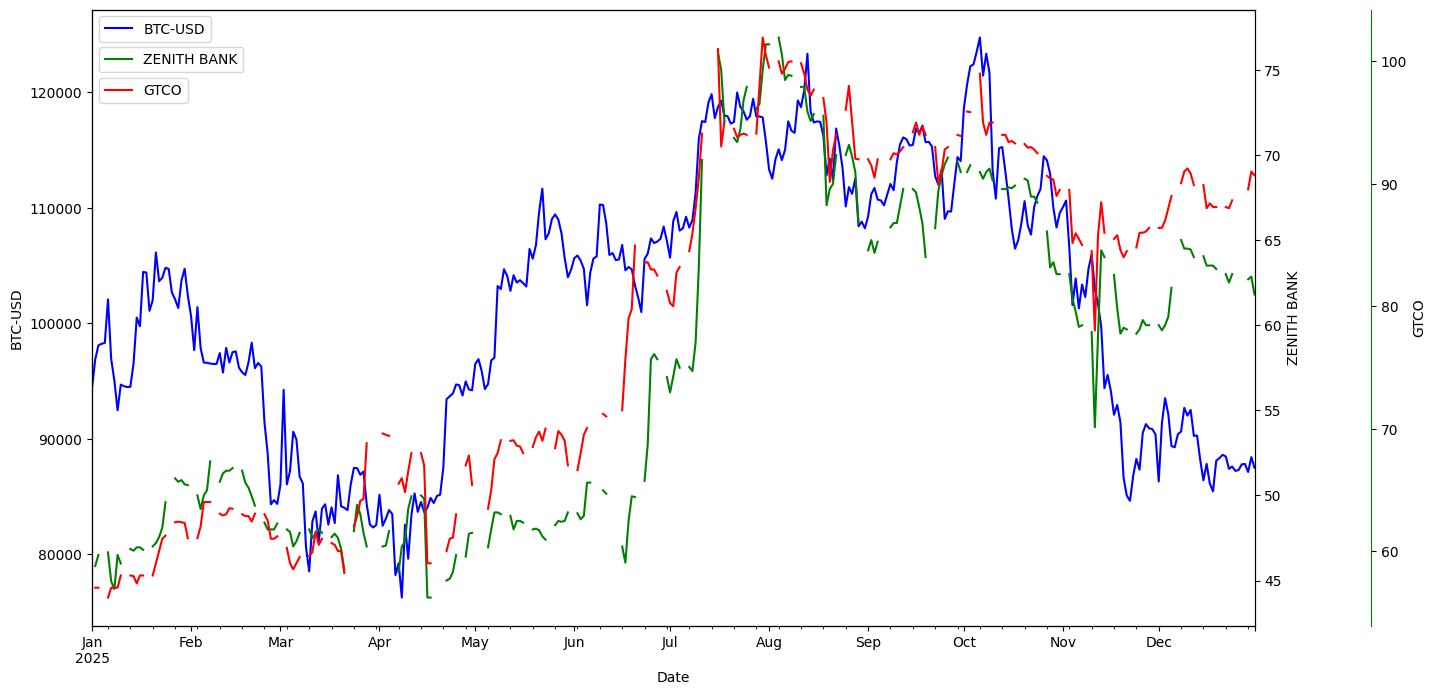

In [15]:
from matplotlib import legend
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines['right'].set_position(('axes', 1.1))
ax3.spines['right'].set_color('green')

df['2025-01-01': '2025-12-31'].plot(ax=ax1, y='BTC-USD', color='blue', label='BTC-USD', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax2, y="ZENITHBANK", color="green", label ='ZENITH BANK', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax3, y="GTCO", color="red", label ='GTCO', legend=True)

ax1.set_ylabel('BTC-USD')
ax2.set_ylabel('ZENITH BANK')
ax3.set_ylabel('GTCO')

ax1.set_xlabel('Date')

ax1.legend(['BTC-USD'], loc='upper left')
ax2.legend(['ZENITH BANK'], loc='upper left',  bbox_to_anchor=(0, 0.95))
ax3.legend(['GTCO'], loc='upper left', bbox_to_anchor=(0, 0.9))

plt.show()

In [16]:
row_1 = df.iloc[0]
row_2 = df.iloc[-2]

btc_price= row_1['BTC-USD']
zenith_price = row_1['ZENITHBANK']
gtco_price = row_1['GTCO']

print("BTC price at 25th March 2019: ", np.round(btc_price, 3))
print("Zenith Bank price at 25th March 2019: ", np.round(zenith_price, 3))
print("GTCO price at 25th March 2019: ", np.round(gtco_price, 3))

BTC price at 25th March 2019:  3963.071
Zenith Bank price at 25th March 2019:  21.5
GTCO price at 25th March 2019:  37.5


In [17]:
# If we invest N100,000 in each, 1USD = N359

btc_shares = (100000/359)/btc_price
zenith_shares = 100000/zenith_price
gtco_shares = 100000/gtco_price

print("BTC shares: ", np.round(btc_shares, 3))
print("Zenith Bank shares: ", np.round(zenith_shares, 3))
print("GTCO shares: ", np.round(gtco_shares, 3))

BTC shares:  0.07
Zenith Bank shares:  4651.163
GTCO shares:  2666.667


In [18]:
#Investment amount at the begining

btc_price_begin =btc_price*btc_shares
zenith_price_begin = zenith_price*zenith_shares
gtco_price_begin = gtco_price*gtco_shares

print(f"BTC price at 25th March 2019: ${np.round(btc_price_begin, 3)} in naira N100000")
print(f"Zenith Bank price at 2019: N{np.round(zenith_price_begin, 3)}")
print(f"GTCO price at 2019: N{np.round(gtco_price_begin, 3)}")

BTC price at 25th March 2019: $278.552 in naira N100000
Zenith Bank price at 2019: N100000.0
GTCO price at 2019: N100000.0


In [19]:
#Investment amount at 23rd march 2026, 1USD = N1390
btc_price_end = row_2['BTC-USD']
zenith_price_end = row_2['ZENITHBANK']
gtco_price_end = row_2['GTCO']

btc_price_end_amount = btc_price_end * btc_shares
zenith_price_end_amount = zenith_price_end * zenith_shares
gtco_price_end_amount = gtco_price_end * gtco_shares

print(f"BTC price 7years after: ${np.round(btc_price_end_amount, 3)} in naira N{np.round(btc_price_end_amount, 3)*1390}")
print(f"Zenith Bank price 7years after: N{np.round(zenith_price_end_amount, 3)}")
print(f"GTCO price 7years after:  N{np.round(gtco_price_end_amount, 3)}")

BTC price 7years after: $4956.474 in naira N6889498.86
Zenith Bank price 7years after: N498604.651
GTCO price 7years after:  N296000.0


In [20]:
btc_return = (btc_price_end_amount - btc_price_begin)/btc_price_begin
zenith_return = (zenith_price_end_amount - zenith_price_begin)/zenith_price_begin
gtco_return = (gtco_price_end_amount - gtco_price_begin)/gtco_price_begin

print(f"BTC return: {np.round(btc_return*100, 3)}%")
print(f"Zenith Bank return: {np.round(zenith_return*100, 3)}%")
print(f"GTCO return: {np.round(gtco_return*100, 3)}%")

BTC return: 1679.374%
Zenith Bank return: 398.605%
GTCO return: 196.0%


# Return in Value After 7 years

If we had invested `N100000` i.e `359USD` at 25th of march 2019, from the result above, our investment had performed differently.

- ZENITHBANK : grow from `N100000` to `N498604.651`
- GTCO : grow from `N100000` to `N296000.0`
- BTC-USD: groe from `359USD` to `$4956.474`, which is from `N100000` to `N6889498.86`

**Also we can see that the three assests performed differently in terms of return:**
- BTC return: 1679.374%
- Zenith Bank return: 398.605%
- GTCO return: 196.0%

Showing the percentage growth of the investment after 6 years.

It is imparative to understand that the values above are just final values, a lot happeend behind the scene. Considering factors such timeframe, investment goal, risk tolerance, and external factors including market volatility, economic conditions, and news related to the company.

Also the above ilustration is a simple comparison between the assets, as I have chosen to use equal investment in all. Sometimes investment value can vary.

In [21]:
prices = df.dropna()
df_return = np.log(prices / prices.shift(1)).dropna()
df_return.head(10)

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2019-03-26 00:00:00+00:00,0.005538,0.009259,-0.002670
2019-03-27 00:00:00+00:00,0.025270,0.013730,-0.038152
2019-03-28 00:00:00+00:00,-0.004404,-0.009132,0.024693
2019-03-29 00:00:00+00:00,0.007167,0.000000,-0.023305
2019-04-01 00:00:00+00:00,0.014488,0.004577,-0.001388
2019-04-02 00:00:00+00:00,0.160042,-0.027780,0.000000
2019-04-03 00:00:00+00:00,0.018907,-0.043172,-0.028171
2019-04-04 00:00:00+00:00,-0.010150,0.004890,0.000000
2019-04-05 00:00:00+00:00,0.022870,-0.007344,0.000000


# Why log return?

## I used log return over simple return because:
- Log returns can be easily added across time to find the cummulative returns over longer period of time.
- Log retruns tend to be more normaly distributed
- log return are more symmetrical than simple return, which is more preferable for financial analysis

In [22]:
avg_annual_return = df_return.mean() * 252
avg_annual_return

,0
BTC-USD,0.420318
ZENITHBANK,0.234574
GTCO,0.158440


In [23]:
avg_daily_return = df_return.mean()
avg_daily_return

,0
BTC-USD,0.001668
ZENITHBANK,0.000931
GTCO,0.000629


## Annualised and Daily Log Return Analysis
### Assets: BTC-USD | Zenith Bank (ZENITHBANK) | Guaranty Trust Holding (GTCO)
### Investment Period: 25 March 2019 — 23 March 2026 (~7 years)
### Base Investment: ₦100,000 (≈ $359 USD at current exchange rate)

---
---

## The Results

| Asset | Daily Log Return | Annual Log Return | Asset Class | Market |
|---|---|---|---|---|
| **BTC-USD** | 0.000861 (0.086%) | 0.216950 (21.70%) | Cryptocurrency | Global |
| **ZENITHBANK** | 0.000978 (0.098%) | 0.246501 (24.65%) | Banking Equity | Nigerian (NGX) |
| **GTCO** | 0.000852 (0.085%) | 0.214723 (21.47%) | Banking Equity | Nigerian (NGX) |

---

## What the Numbers Mean

### BTC-USD: 21.70% Annual Log Return
Bitcoin delivered approximately **21.7% per year** on average over this 7-year period.
This is a strong return by any global standard, but it came with extreme volatility —
Bitcoin experienced single-day crashes of up to -46% during this period.

**Future value of ₦100,000 invested in Bitcoin (7 years):**
```python
import numpy as np
fv_btc = 100_000 * np.exp(0.216950 * 7)
print(f"₦{fv_btc:,.0f}")   # ≈ ₦467,217
```
> A ₦100,000 investment in Bitcoin in March 2019 would be worth approximately
> **₦467,217 by March 2026** — a 4.67x return in Naira terms.

---

### ZENITHBANK: 24.65% Annual Log Return — The Best Performer
Zenith Bank delivered the **highest risk-adjusted annual return** among the three assets,
at 24.65% per year. This is particularly notable because:

- It is a **Nigerian domestic equity** — meaning it reflects the Nigerian economy directly
- It **outperformed Bitcoin** on average annual return over this period
- Unlike Bitcoin, it is subject to NGX trading hours and Nigerian regulatory oversight

**Future value of ₦100,000 invested in Zenith Bank (7 years):**
```python
fv_zenith = 100_000 * np.exp(0.246501 * 7)
print(f"₦{fv_zenith:,.0f}")   # ≈ ₦561,073
```
> A ₦100,000 investment in Zenith Bank in March 2019 would be worth approximately
> **₦561,073 by March 2026** — a 5.61x return in Naira terms.

**Important context:** This period (2019–2026) captured Zenith Bank's significant
growth driven by Nigeria's post-COVID economic recovery, naira devaluation (which
inflated Naira-denominated stock prices), and strong banking sector earnings growth.
Past performance does not guarantee future results.

---

### GTCO: 21.47% Annual Log Return
Guaranty Trust Holding Company delivered approximately **21.47% per year**, placing
it very close to Bitcoin's return. GTCO is consistently one of the most liquid and
best-governed banks on the NGX, known for strong dividend payments alongside
capital appreciation.

**Future value of ₦100,000 invested in GTCO (7 years):**
```python
fv_gtco = 100_000 * np.exp(0.214723 * 7)
print(f"₦{fv_gtco:,.0f}")   # ≈ ₦457,534
```
> A ₦100,000 investment in GTCO in March 2019 would be worth approximately
> **₦457,534 by March 2026** — a 4.58x return in Naira terms.

---

## 4. Comparative Summary
```python
assets = ['BTC-USD', 'ZENITHBANK', 'GTCO']
annual_returns = [0.216950, 0.246501, 0.214723]
investment = 100_000

print(f"{'Asset':<15} {'Annual Return':>15} {'Future Value (₦)':>18} {'Multiple':>10}")
print("-" * 60)
for asset, r in zip(assets, annual_returns):
    fv = investment * np.exp(r * 7)
    multiple = fv / investment
    print(f"{asset:<15} {r*100:>14.2f}%  ₦{fv:>15,.0f}  {multiple:>8.2f}x")
```

| Asset | Annual Return | Future Value (₦) | Multiple |
|---|---|---|---|
| BTC-USD | 21.70% | ₦467,217 | 4.67x |
| **ZENITHBANK** | **24.65%** | **₦561,073** | **5.61x** |
| GTCO | 21.47% | ₦457,534 | 4.58x |

---

## Key Financial Insights

### Return Alone Does Not Tell the Full Story
These annual returns represent the **average growth** over 7 years. They do not
capture **how bumpy the journey was**. Bitcoin's path to 4.67x included devastating
crashes (e.g., -80% from peak in 2022). Zenith Bank's path to 5.61x included the
turbulence of naira devaluation and Nigerian economic uncertainty.

The next step in our analysis — computing **standard deviation**, **semivariance**,
and the **Sharpe Ratio** — will reveal which asset delivered the best return
*per unit of risk taken*.

### The Naira Devaluation Effect
It is critical to note that Nigerian equity returns are measured in **Naira terms**.
During 2019–2026, the Nigerian Naira depreciated significantly against the US Dollar
(from approximately ₦360/$ to ₦1,500/$). This means:

- Zenith Bank's 24.65% Naira return may translate to a **negative USD return**
  when adjusted for currency depreciation
- Bitcoin's 21.70% return is already in **USD terms**, making it directly
  comparable to international benchmarks
- A proper comparison requires **USD-adjusted returns** for Nigerian equities

This is a real-world illustration of **currency risk** — an important consideration
for any investor in emerging market equities.

### Relevance to Different Stakeholders

**For the ordinary Nigerian investor:**
All three assets grew a ₦100,000 investment to over ₦450,000 over 7 years —
far outpacing a typical Nigerian savings account rate. However, the journey required
tolerance for significant volatility, particularly for Bitcoin.

**For the financial engineer:**
These log returns are the inputs to every downstream analysis: volatility estimation,
correlation matrices, Cholesky simulation, and VaR calculation. The similarity between
GTCO and Bitcoin returns (21.47% vs 21.70%) sets up an interesting portfolio
optimisation problem — can combining them reduce risk without sacrificing return?

**For the data scientist:**
The daily return series (mean ~0.00086–0.00098) are approximately zero-mean,
which satisfies one condition for stationarity. The next step is to test whether
the variance is also constant (ARCH effects test) and whether the distributions
are normal (Jarque-Bera test) before applying any parametric models.

---

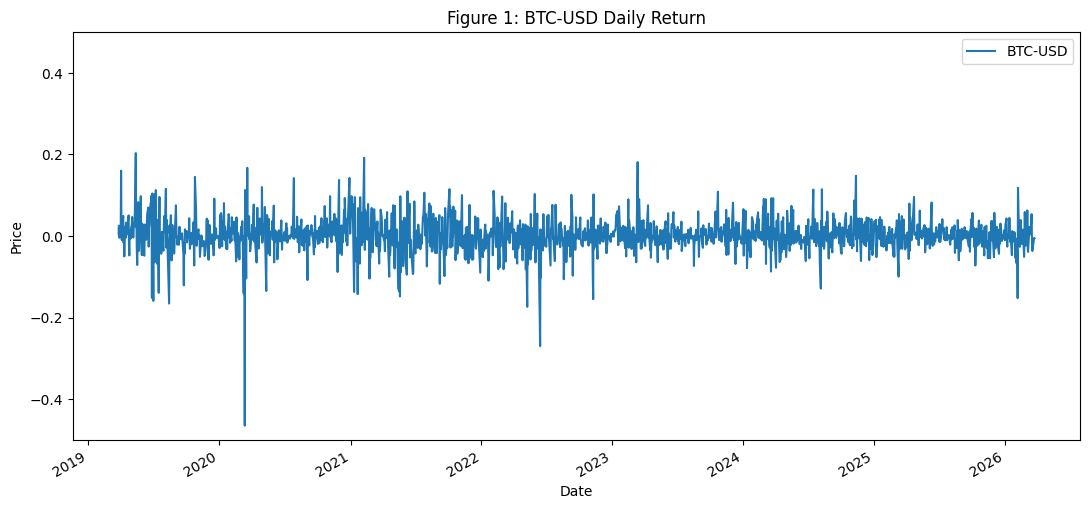

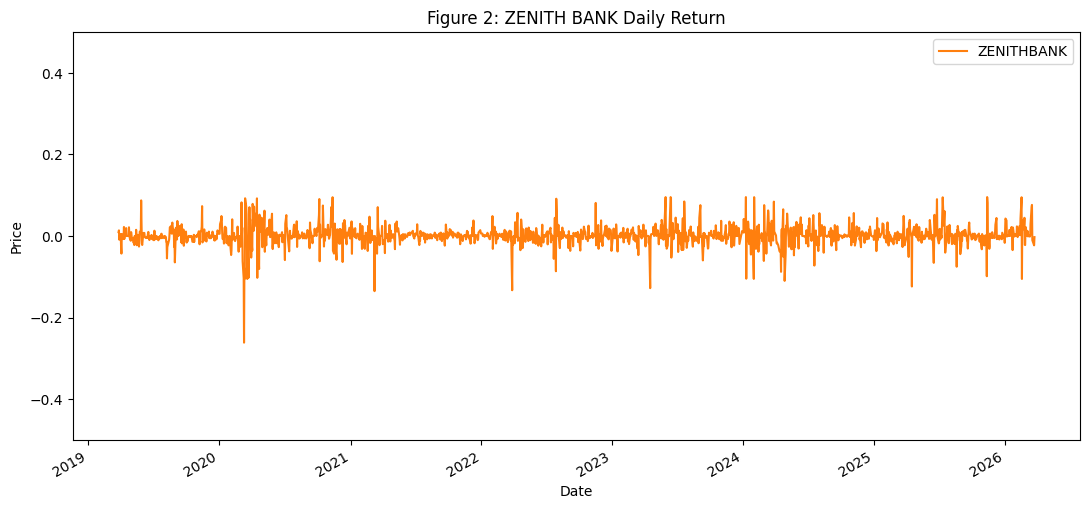

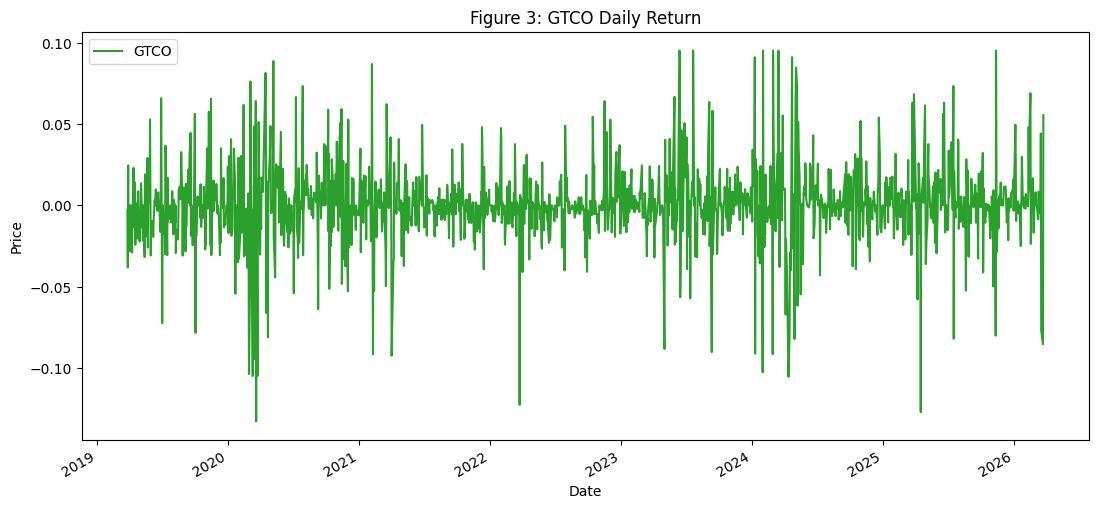

In [24]:
ax1 = df_return.plot(figsize=(13,6), y='BTC-USD', title='Figure 1: BTC-USD Daily Return')
ax2 = df_return.plot(figsize=(13,6), y='ZENITHBANK', title='Figure 2: ZENITH BANK Daily Return', c="C1")
ax3 = df_return.plot(figsize=(13,6), y='GTCO', title='Figure 3: GTCO Daily Return', c="C2")

ax1.set_ylabel('Price')
ax1.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.set_xlabel('Date')
ax3.set_ylabel('Price')
ax3.set_xlabel('Date')


ax1.set_ylim(-0.5, 0.5)
ax2.set_ylim(-0.5, 0.5)

plt.show()

In [25]:
df.tail()

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2026-03-21 00:00:00+00:00,"68,711.523438",NaN,NaN
2026-03-22 00:00:00+00:00,"67,845.210938",NaN,NaN
2026-03-23 00:00:00+00:00,"70,914.859375",107.500000,105.000000
2026-03-24 00:00:00+00:00,"70,517.859375",107.200000,111.000000
2026-03-25 00:00:00+00:00,NaN,106.850000,114.550000


In [26]:
#High_low Volatility BTC

end = pd.Timestamp(df.index[-2])
curr_year = df.loc[end - pd.Timedelta(days=365) : end]

(curr_year.max() - curr_year.min())/df.iloc[-2]

,0
BTC-USD,0.879925
ZENITHBANK,0.626399
GTCO,0.581081


# High-Low Volatility

Volatility reflect the jumpiness of the stock, from the above, BTC-USD has the hihest volatility value, ZENITHBANK and GTCO have approximately similar volatitlity, but ZENITHBANK is slightly higher.

Overall, the three stocks are highly volatile, showing that they have considerable risk, although some are riskier compared to others.

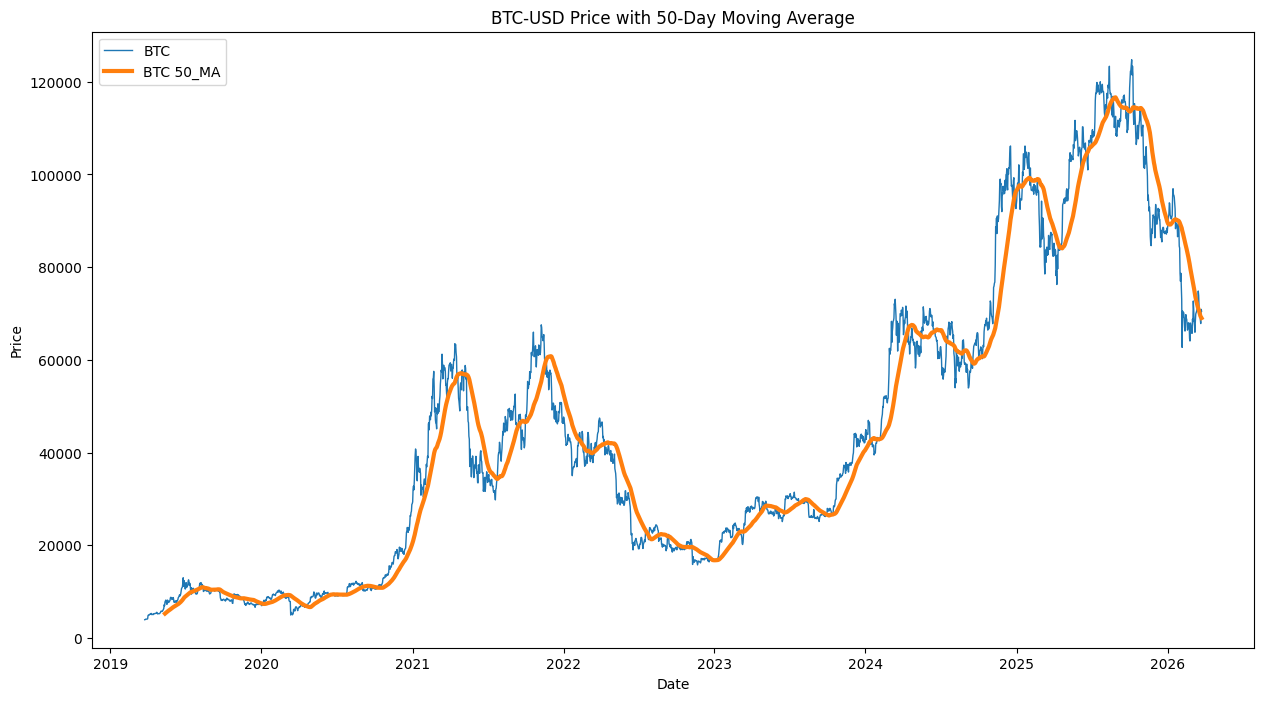

In [27]:
# Moving Avg BTC
df['BTC 50_MA'] = df['BTC-USD'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['BTC-USD'], label='BTC', linewidth=1)
plt.plot(df.index, df['BTC 50_MA'], label='BTC 50_MA',
         linewidth=3)

plt.legend()
plt.title('BTC-USD Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_2674/1233982977.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices['ZENITHBANK 50_MA'] = prices['ZENITHBANK'].rolling(window=50).mean()


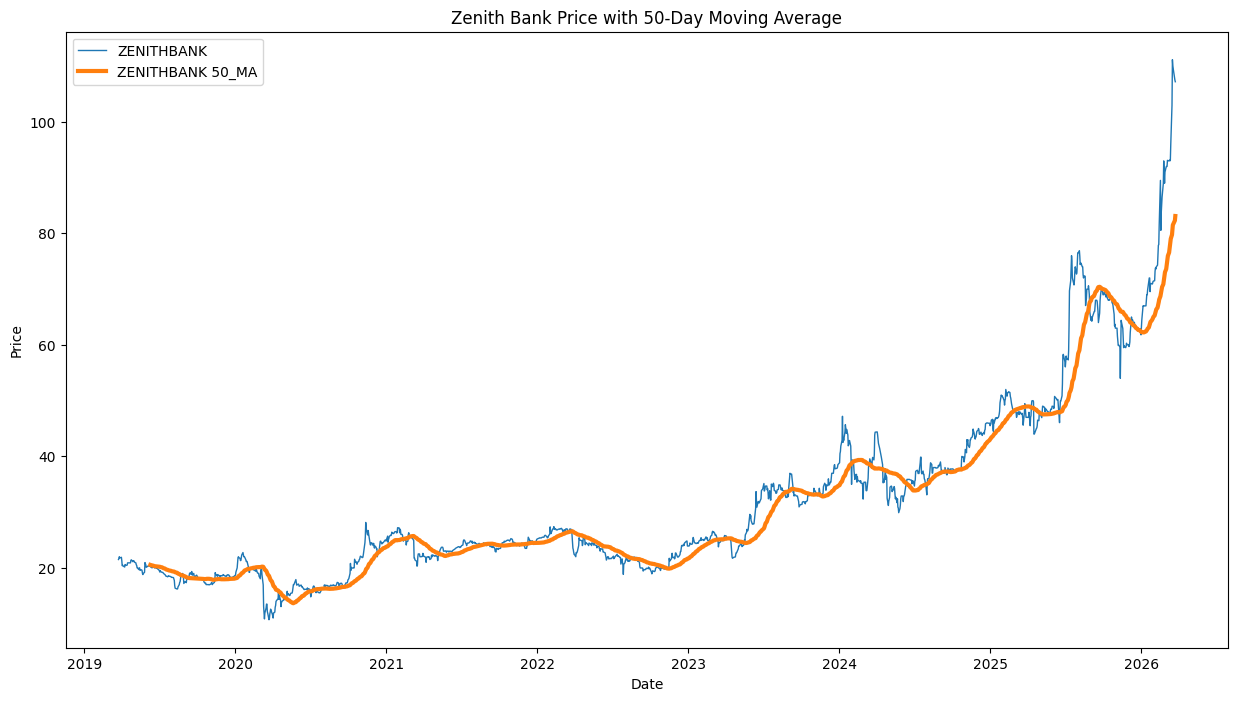

In [28]:
# Moving Avg ZENITH
prices['ZENITHBANK 50_MA'] = prices['ZENITHBANK'].rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(prices.index, prices['ZENITHBANK'], label='ZENITHBANK', linewidth=1)
plt.plot(prices.index, prices['ZENITHBANK 50_MA'], label='ZENITHBANK 50_MA',
         linewidth=3)

plt.legend()
plt.title('Zenith Bank Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_2674/4124969363.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices['GTCO 50_MA'] = prices['GTCO'].rolling(window=50).mean()


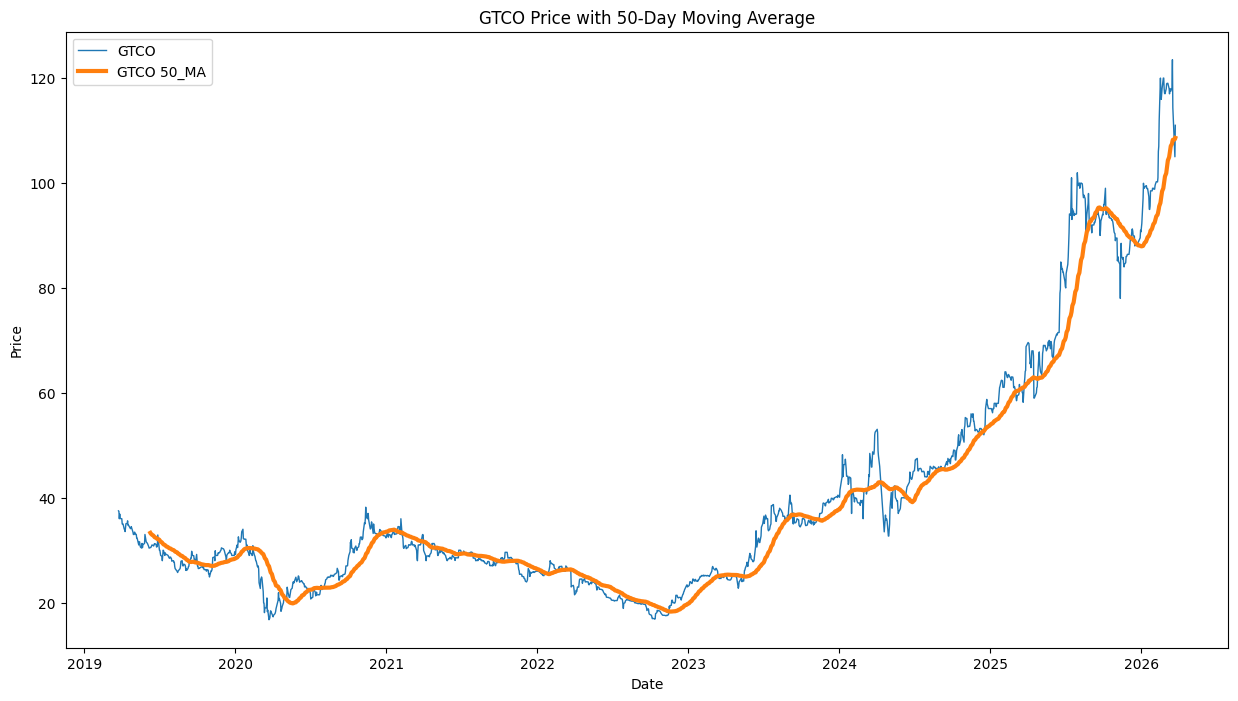

In [29]:
# Moving Average GTCO

prices['GTCO 50_MA'] = prices['GTCO'].rolling(window=50).mean()

plt.figure(figsize=(15, 8))
plt.plot(prices.index, prices['GTCO'], label='GTCO', linewidth=1)
plt.plot(prices.index, prices['GTCO 50_MA'], label='GTCO 50_MA',
         linewidth=3)

plt.legend()
plt.title('GTCO Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [30]:
# Rolling distance

(abs(df - df.dropna().rolling(window=50).mean())/df).mean()

,0
BTC-USD,0.128978
ZENITHBANK,0.069505
GTCO,0.070602
BTC 50_MA,0.111299


In [31]:
(abs(prices - prices.dropna().rolling(window=50).mean())/prices).mean()

,0
BTC-USD,0.129703
ZENITHBANK,0.069223
GTCO,0.070383
ZENITHBANK 50_MA,0.050136
GTCO 50_MA,0.053114


# Rolling Distance 50_MA

The result above provides a measure of how much on average the daily prices deviate from their 50 day rolling average, in percentage.

BTC-USD having the highest value `0.128978` approximately 12% shows greater fluntuation in the stock, this imply it is highly  volatile compared to ZENITHBANK `0.069223` and GTCO `0.070383`, which are approximately 7%

The rolling distance for all moving averages appeared to be less in all stocks as the moving averages are smoother compared to the original data


These values can be useful for understanding the relative volatility of different assets and how much daily prices tend to deviate from their longer-term trends.

In [32]:
# Standard Deviations

df_return.std()

,0
BTC-USD,0.040775
ZENITHBANK,0.024284
GTCO,0.023016


# Standard deviation

Here again, BTC-USD has a hight std suggesting it has been more volatile over the last 7 years

In [33]:
# sharpe ratio

sharpe_ratio = np.sqrt(252) * (df_return.mean() / df_return.std())
sharpe_ratio

,0
BTC-USD,0.649352
ZENITHBANK,0.608493
GTCO,0.433645


# Sharpe Ratio

Based on these results, the sharpe ratio provides information on risk-adjusted over the analyzed period. From the above result, it is clear ZENITHBANK provide a better return per unit risk compared to GTCO

In [34]:
# Semivariance

mean_returns = df_return.mean()
semivariance = (df_return[df_return < mean_returns] - mean_returns)**2
semi_var = semivariance.mean()

semi_var

,0
BTC-USD,0.001696
ZENITHBANK,0.000568
GTCO,0.000482


# Semi-Variance

The semivariance tells a better story comapred to the sharpe ratio, it shows the downside of the risk which is what most investors are interested to know.

BTC-USD, has a much high variance ~3X ZENITHBANK and ~3.5X GTCO.
This indicate that BTC has experienced significanlty larger  negative deviations from its average return, which is a higher downside risk

In [35]:
def InvestmentComparison(startTime, endTime, df):
  startTime = pd.Timestamp(startTime).tz_localize('UTC')
  endTime = pd.Timestamp(endTime).tz_localize('UTC')

  returns = np.log(df)-np.log(df.shift(1))
  returns = returns.iloc[1:, 0:]

  curr_year= df.loc[endTime - pd.Timedelta(days=365) : endTime]


  highlow_series = (curr_year.max() - curr_year.min()) / df.iloc[-2]


  # Calculate MA as a Series, considering only original asset columns
  ma_series = (abs(df - df.dropna().rolling(window=50).mean())/df).mean()

  # Calculate std as a Series
  std_series = returns.std()

  # Calculate daily return as a Series
  daily_return_series = returns.mean()

  # Sharpe ratio
  sharpe_ratio = np.sqrt(252) * (daily_return_series / std_series)

  # Semi-variance
  mean_returns = df_return.mean()
  semivariance = (df_return[df_return < mean_returns] - mean_returns)**2
  semi_var = semivariance.mean()

  # Combine all Series into a single DataFrame
  investment = pd.DataFrame({
      'highlow': highlow_series,
      'MA': ma_series,
      'std': std_series,
      'daily return': daily_return_series,
      'sharpe ratio': sharpe_ratio,
      'semi-variance': semi_var
  })

  # Format the columns
  investment['highlow'] = investment['highlow'].round(4).astype(str)

  # Format other columns as percentages
  for col_name in ["std", "daily return", 'MA']:
    investment[col_name] = (investment[col_name]*100).round(3).astype(str) + '%'

  return investment

In [36]:
InvestmentComparison('2020-01-01', '2026-01-01', df_test)

,highlow,MA,std,daily return,sharpe ratio,semi-variance
BTC-USD,0.6875,13.111%,3.305%,0.113%,0.540933,0.001696
ZENITHBANK,0.3069,6.886%,2.418%,0.098%,0.641965,0.000568
GTCO,0.4122,7.041%,2.227%,0.087%,0.623573,0.000482


In [37]:
InvestmentComparison('2024-01-01', '2025-01-01', df_test)

,highlow,MA,std,daily return,sharpe ratio,semi-variance
BTC-USD,0.9449,13.111%,3.305%,0.113%,0.540933,0.001696
ZENITHBANK,0.1613,6.886%,2.418%,0.098%,0.641965,0.000568
GTCO,0.2347,7.041%,2.227%,0.087%,0.623573,0.000482


In [38]:
# Covariance

df_return.cov()

,BTC-USD,ZENITHBANK,GTCO
BTC-USD,0.001663,0.000029,0.000039
ZENITHBANK,0.000029,0.000590,0.000327
GTCO,0.000039,0.000327,0.000530


# Covariance

All the values in the above matrix are positive, indicating that they move together in the same direction. In simple term this implies that, if the value of ZENITHBANK goes up, the value of GTCO will go up as well


In [39]:
# Correlation

df_return.corr()

,BTC-USD,ZENITHBANK,GTCO
BTC-USD,1.000000,0.029240,0.041549
ZENITHBANK,0.029240,1.000000,0.585408
GTCO,0.041549,0.585408,1.000000


# Correlation

Correlation provides a clearer picture as we could tell easily how much relationship positive or negative stocks have on each other.

ZENITHBANK and GTCO are moderately correlated, while both stocks have approximately no correlation with BTC-USD

The correlations are show in the charts below

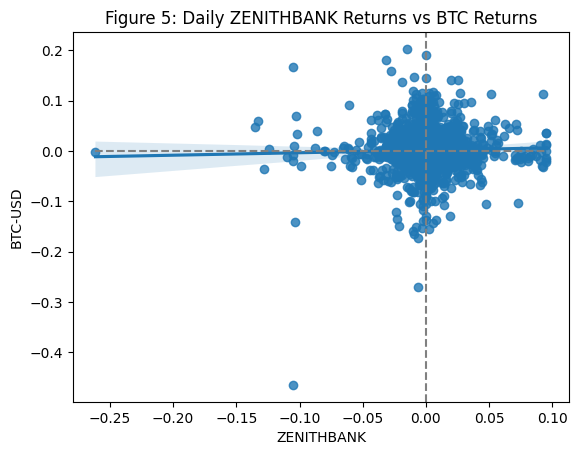

In [40]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="ZENITHBANK", y="BTC-USD", data=df_return).set(
    title="Figure 5: Daily ZENITHBANK Returns vs BTC Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['ZENITHBANK']), max(df_return['ZENITHBANK'])], [0, 0], linestyle="--", color="grey");

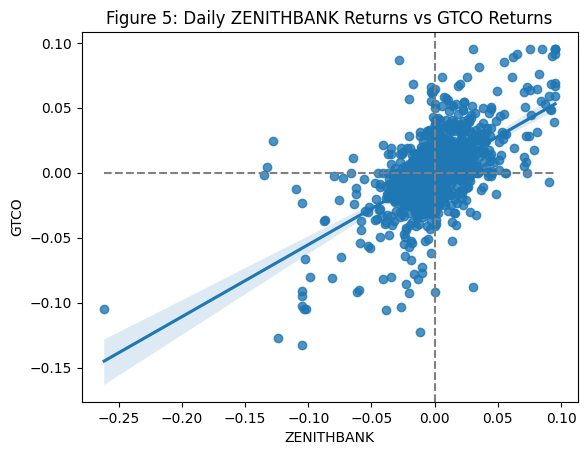

In [41]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="ZENITHBANK", y="GTCO", data=df_return).set(
    title="Figure 5: Daily ZENITHBANK Returns vs GTCO Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['ZENITHBANK']), max(df_return['ZENITHBANK'])], [0, 0], linestyle="--", color="grey");

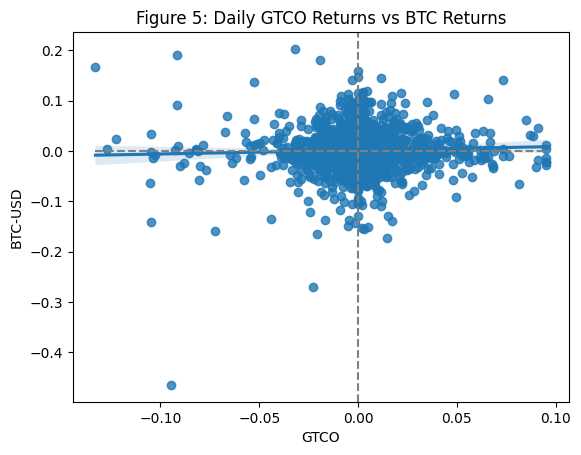

In [42]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="GTCO", y="BTC-USD", data=df_return).set(
    title="Figure 5: Daily GTCO Returns vs BTC Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['GTCO']), max(df_return['GTCO'])], [0, 0], linestyle="--", color="grey");

# Normality Test

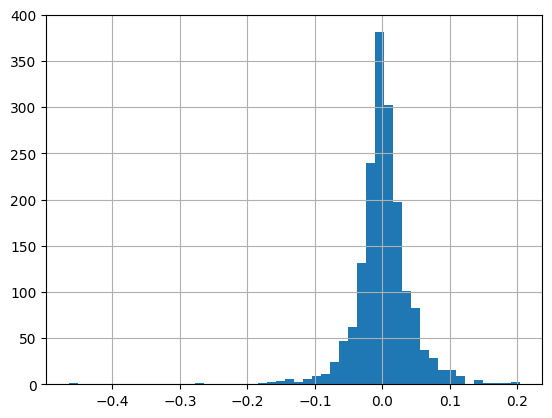

In [43]:
df_return['BTC-USD'].hist(bins=50);

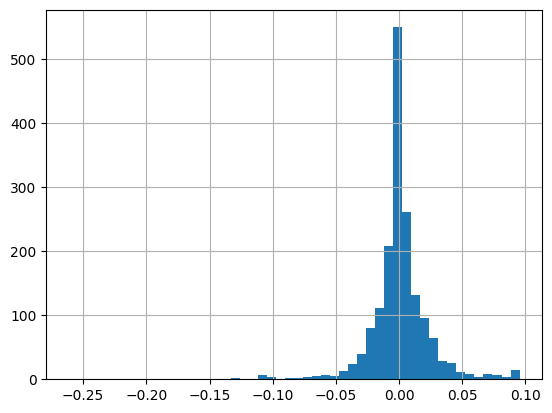

In [44]:
df_return["ZENITHBANK"].hist(bins=50);

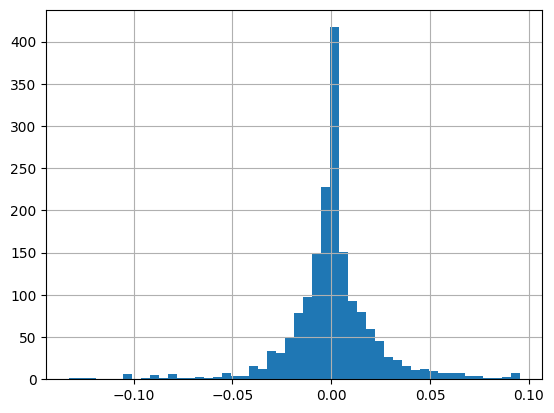

In [45]:
df_return["GTCO"].hist(bins=50);

In [46]:
from scipy import stats

In [47]:
#D'Agostino and Pearson's normality test

stats.normaltest(df_return['BTC-USD'])

NormaltestResult(statistic=np.float64(548.2889499330462), pvalue=np.float64(8.721019905858101e-120))

In [48]:
stats.normaltest(df_return['ZENITHBANK'])

NormaltestResult(statistic=np.float64(551.6011413626917), pvalue=np.float64(1.6646925936360274e-120))

In [49]:
stats.normaltest(df_return['GTCO'])

NormaltestResult(statistic=np.float64(261.06957903364264), pvalue=np.float64(2.0392065453521093e-57))

# D'Agostino and Pearson's normality test

This method combined skew and kurtosis to test for normality of the distribution, A higher statistic and low p-value(less that 0.05), indicate the distribution is not normally distributed.

From the above normality test, the test statistics and p-values for the three assests provide strong evidence to reject the null hypothesis that the distributions are normal


In [50]:
# Jacque bera

stats.jarque_bera(df_return['BTC-USD'])

SignificanceResult(statistic=np.float64(12990.858337246871), pvalue=np.float64(0.0))

In [51]:
stats.jarque_bera(df_return['ZENITHBANK'])

SignificanceResult(statistic=np.float64(13248.502935177188), pvalue=np.float64(0.0))

In [52]:
stats.jarque_bera(df_return['GTCO'])

SignificanceResult(statistic=np.float64(2742.1579182645914), pvalue=np.float64(0.0))

# Jacque bera : Testing Skewness and Kurtosis

The further the test statistic is from zero, and the p-value is to zero  indicate that the distribution does not follow normality.

This situation is evident from our results, confirmimg what the normality test obtain

In [53]:
# minimum and maximum daily log returns
dfMax = df_return['ZENITHBANK'].max()
dfMin = df_return['ZENITHBANK'].min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df_return['ZENITHBANK'].max() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()
num_dev_min = (df_return['ZENITHBANK'].min() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))

Maximum return of sample data is:  0.09531
Minimum return of sample data is:  -0.26148
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  3.88645
Number of standard deviations from the mean for the minimum return:  -10.80582


# Where the distribution break the normality behaviour

Due to the fat tails in all assets returns distribution, this implies we have some extreme events greater than or less than (+/- 3 std away from the mean)

This output provides valuable insights into the distribution of ZENITHBANK log returns, particularly highlighting the presence of outliers or fat tails:

 - Maximum and Minimum Returns: The maximum daily return of approximately 9.531% and the minimum daily return of approximately -26.148% show the range of returns observed in our data.
 - Z-scores: The z-scores for the maximum and minimum returns are 3.88645 and -10.80582, respectively. These are extremely high z-scores, indicating that both the maximum and minimum returns are significant outliers, far away from the mean in terms of standard deviations.

In a normal distribution, you would rarely observe data points more than 3 standard deviations away from the mean. These high z-scores suggest that the S&P 500 daily returns have fatter tails than a normal distribution, meaning extreme events (large positive or negative returns) are more likely than would be expected under normality.

This information is crucial for risk management and modeling, as relying on the assumption of normality can lead to underestimating the probability of extreme events and potential losses.

These standard deviations are humongous when compared to the normal distribution. We can see this analytically when we plug in the z score to the `norm.cdf()` method to determine the probability this value could be in a normal distribution:

In [54]:
stats.norm.cdf(-10.85213)

np.float64(9.74156552742683e-28)

This implies that the chance we could have a move as small as -26.148% is 9.74156552742683e-28. This probability is so low that we would never expect an event like this to happen in our lifetime. We have multiple events like this, as illustrated by the minimum and maximum.

Going further with this idea, based on normal distribution z tables, we would expect 99.7% of our data points to be within +/- 3 standard deviations from the mean. Let's determine this for our sample data. First off, we need to find the cut-off values at +/- 3 standard deviations:

In [55]:
# Calculates the upper and lowers bounds
upper = (3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()
lower = (-3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))

Upper bound:  0.07378
Lower bound:  -0.07192


In [89]:
print(len(df_return['ZENITHBANK']))

print(0.997 * 1726)
print(0.03 * 1726)
print(47/1726)

1726
1720.822
51.78
0.027230590961761298


The above two calculations would imply that 99.7% of all of our data points should be in between -0.07192 and 0.07378.

Since we have 1726 data points, we would expect about 51 (i.e., .03% of 1726) of them to be outside of that range if normality was held. Now let's see how many we actually have.

In [57]:
# Calculates the number of data points
len(df_return[(df_return['ZENITHBANK'] < lower) | (df_return['ZENITHBANK'] > upper)])

47

In [58]:
# minimum and maximum daily log returns
dfMax = df_return['GTCO'].max()
dfMin = df_return['GTCO'].min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df_return['GTCO'].max() - df_return['GTCO'].mean()) / df_return['GTCO'].std()
num_dev_min = (df_return['GTCO'].min() - df_return['GTCO'].mean()) / df_return['GTCO'].std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))

Maximum return of sample data is:  0.09531
Minimum return of sample data is:  -0.13285
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  4.11372
Number of standard deviations from the mean for the minimum return:  -5.7993


In [59]:
stats.norm.cdf(-6.00432)

np.float64(9.606771627286962e-10)

In [90]:
print(len(df_return['GTCO']))

print(0.997 * 1726)
print(0.03 * 1726)
print(47/1726)

1726
1720.822
51.78
0.027230590961761298


In [60]:
# Calculates the upper and lowers bounds
upper = (3 * df_return['GTCO'].std()) + df_return['GTCO'].mean()
lower = (-3 * df_return['GTCO'].std()) + df_return['GTCO'].mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))

Upper bound:  0.06968
Lower bound:  -0.06842


In [61]:
# Calculates the number of data points
len(df_return[(df_return['GTCO'] < lower) | (df_return['GTCO'] > upper)])

42

Original rows: 1726
After removing zeros: 1495
count   1,495.000000
mean        0.001075
std         0.026091
min        -0.261480
25%        -0.008351
50%         0.001513
75%         0.010743
max         0.095310
Name: ZENITHBANK, dtype: float64

Fitted parameters: df=2.07, loc=0.000651, scale=0.012647


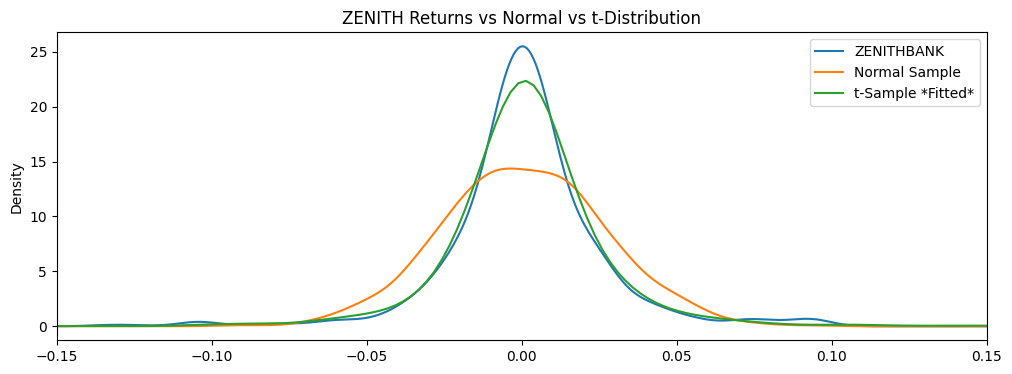

In [62]:
# Step 1: Remove zero returns before fitting
zenith_returns = df_return['ZENITHBANK']
zenith_clean = zenith_returns[zenith_returns != 0].dropna()

print(f"Original rows: {len(zenith_returns)}")
print(f"After removing zeros: {len(zenith_clean)}")
print(zenith_clean.describe())

# Step 2: Fit t-distribution to cleaned returns
params = stats.t.fit(zenith_clean)
print(f"\nFitted parameters: df={params[0]:.2f}, loc={params[1]:.6f}, scale={params[2]:.6f}")

# Step 3: Generate fitted samples
fitted_samples = stats.t.rvs(*params, size=len(zenith_clean))

# Step 4: Normal distribution sample for comparison
normal_samples = np.random.normal(
    loc=zenith_clean.mean(),
    scale=zenith_clean.std(),
    size=len(zenith_clean)
)

# Step 5: Plot
plot_df = pd.DataFrame({
    'ZENITHBANK': zenith_clean.values,
    'Normal Sample': normal_samples,
    't-Sample *Fitted*': fitted_samples
})

plot_df.plot(kind='kde', figsize=(12, 4), xlim=(-0.15, 0.15))
plt.title('ZENITH Returns vs Normal vs t-Distribution')
plt.show()

Original rows: 1726
After removing zeros: 1502
count   1,502.000000
mean        0.000722
std         0.024672
min        -0.132848
25%        -0.009046
50%         0.000887
75%         0.010582
max         0.095310
Name: GTCO, dtype: float64

Fitted parameters: df=2.13, loc=0.000228, scale=0.012655


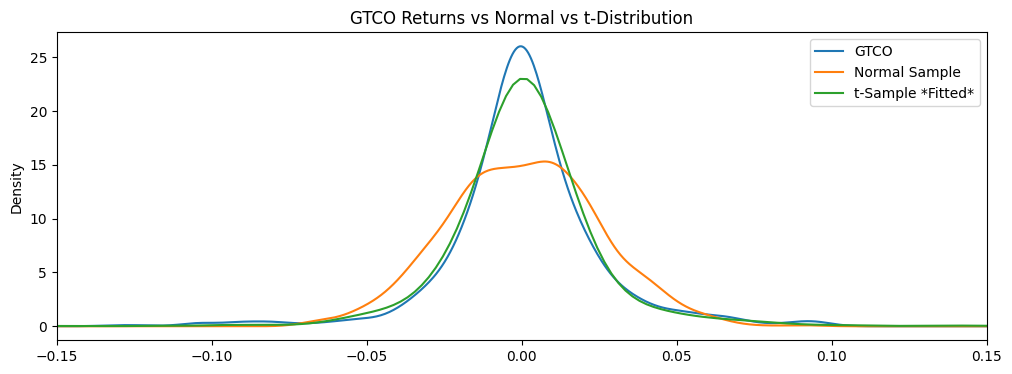

In [63]:
# Step 1: Remove zero returns before fitting
gt_returns = df_return['GTCO']
gt_clean = gt_returns[gt_returns != 0].dropna()

print(f"Original rows: {len(gt_returns)}")
print(f"After removing zeros: {len(gt_clean)}")
print(gt_clean.describe())

# Step 2: Fit t-distribution to cleaned returns
params = stats.t.fit(gt_clean)
print(f"\nFitted parameters: df={params[0]:.2f}, loc={params[1]:.6f}, scale={params[2]:.6f}")

# Step 3: Generate fitted samples
fitted_samples = stats.t.rvs(*params, size=len(gt_clean))

# Step 4: Normal distribution sample for comparison
normal_samples = np.random.normal(
    loc=gt_clean.mean(),
    scale=gt_clean.std(),
    size=len(gt_clean)
)

# Step 5: Plot
plot_df = pd.DataFrame({
    'GTCO': gt_clean.values,
    'Normal Sample': normal_samples,
    't-Sample *Fitted*': fitted_samples
})

plot_df.plot(kind='kde', figsize=(12, 4), xlim=(-0.15, 0.15))
plt.title('GTCO Returns vs Normal vs t-Distribution')
plt.show()

In [92]:
df_return['ZENITHBANK'].kurt()

np.float64(13.4858349687213)

The distribution is leptokurtic, because the kurtosis is greater than 3

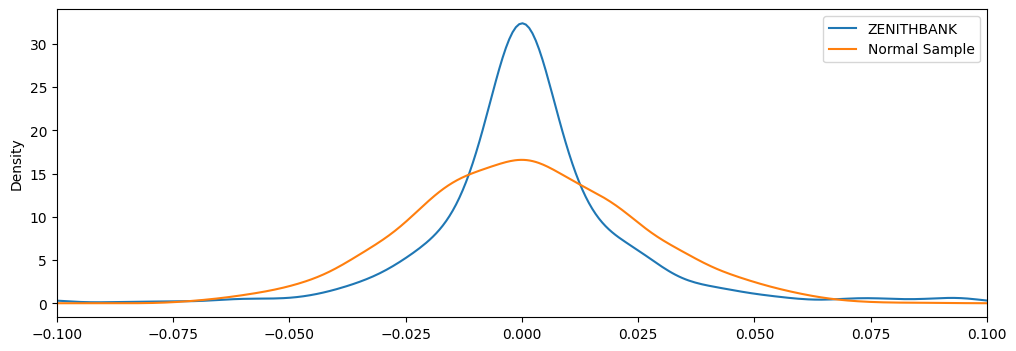

In [64]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['ZENITHBANK'] ), loc = df_return['ZENITHBANK'].mean(), scale = df_return['ZENITHBANK'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

In [91]:
df_return['GTCO'].kurt()

np.float64(6.158434870024622)

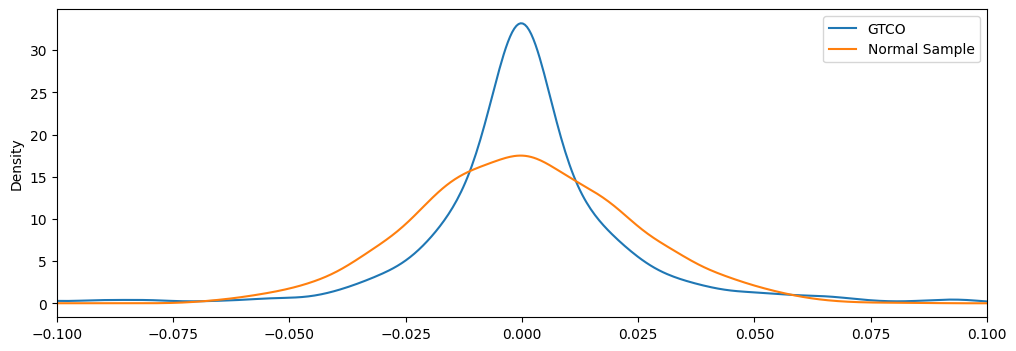

In [65]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['GTCO'] ), loc = df_return['GTCO'].mean(), scale = df_return['GTCO'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

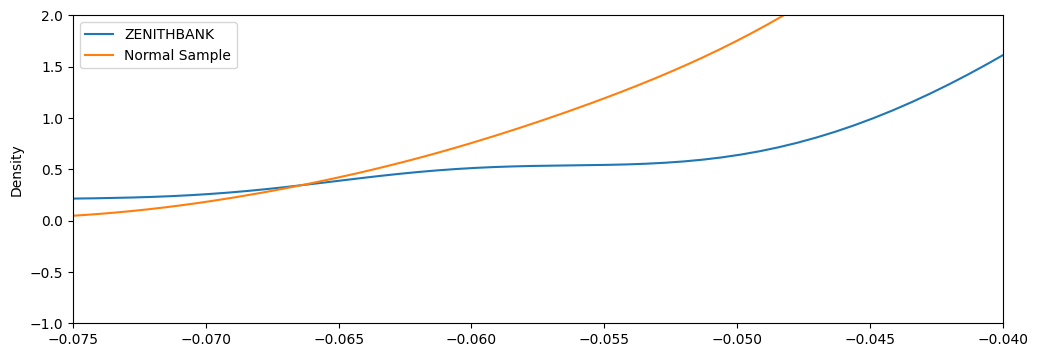

In [66]:
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

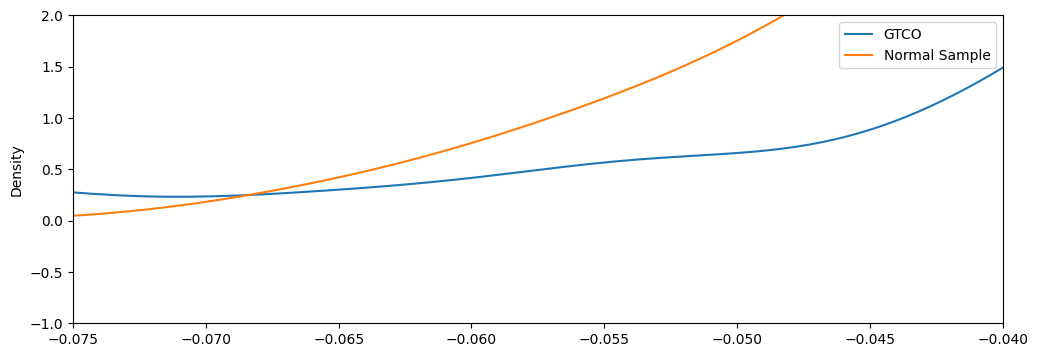

In [67]:
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

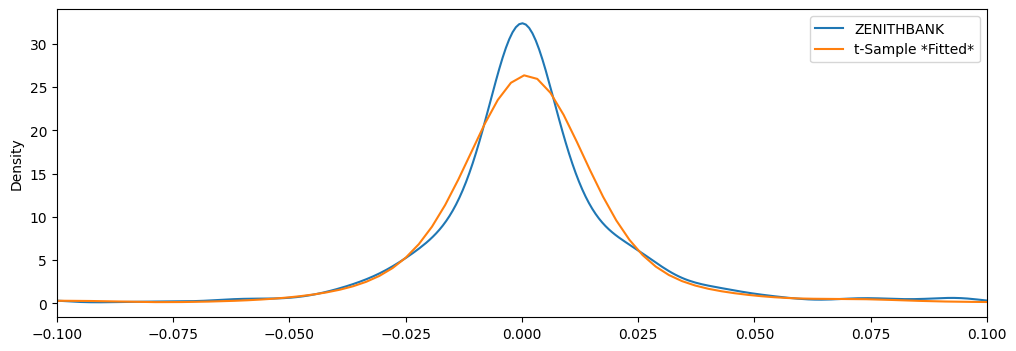

In [68]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['ZENITHBANK'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

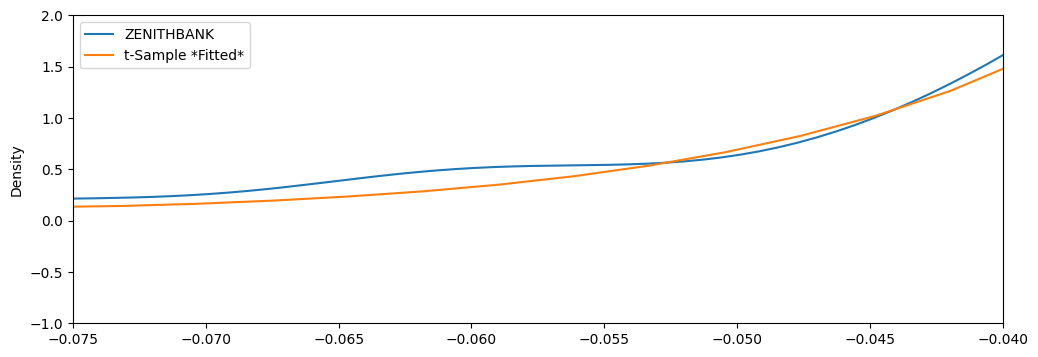

In [69]:
# Plot left tail area
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

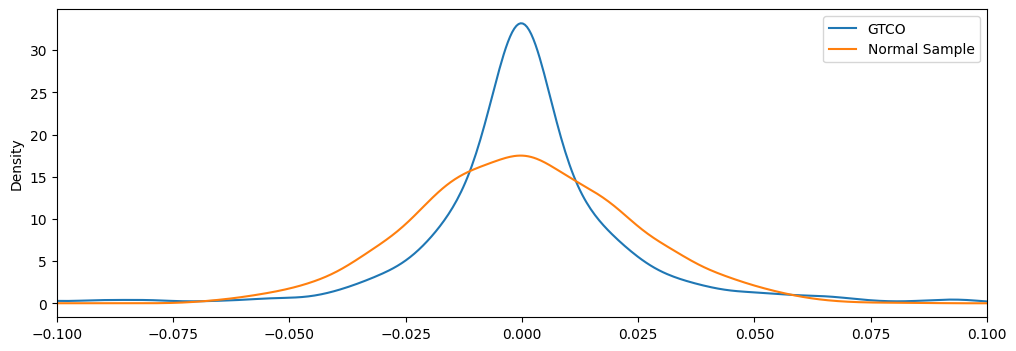

In [70]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['GTCO'] ), loc = df_return['GTCO'].mean(), scale = df_return['GTCO'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

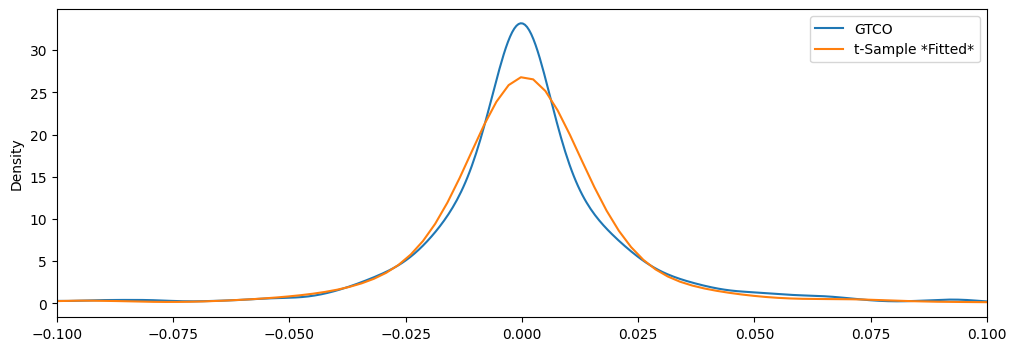

In [71]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['GTCO'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['GTCO', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

# Using Cholesky Factorization for Monte Carlo Simulation

Cholesky factorization is useful in Monte Carlo simulations to generate correlated random variables



In [72]:
def is_positive_definite(matrix):
    return np.all(np.linalg.eigvals(matrix) > 0)

A = df_return.corr()

print("Is A positive definite?", is_positive_definite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive definite? True
Eigenvalues: [1.59173807 0.41406548 1.06781831 0.97375526 0.95262288]
Determinant: 0.6528431011253163
Rank: 5


In [73]:
def is_positive_semidefinite(matrix):
    return np.all(np.linalg.eigvals(matrix) >= 0)

A = df_return.corr()

print("Is A positive semidefinite?", is_positive_semidefinite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive semidefinite? True
Eigenvalues: [1.59173807 0.41406548 1.06781831 0.97375526 0.95262288]
Determinant: 0.6528431011253163
Rank: 5


In [74]:
new_corr = df_return[['GTCO', 'ZENITHBANK']].corr()
new_corr

,GTCO,ZENITHBANK
GTCO,1.000000,0.585408
ZENITHBANK,0.585408,1.000000


In [75]:
# Create a function to generate random samples for the given stock pair
def generate_correlated_stock_samples(n_samples, stock_returns):

    # Compute correlation matrix
    correlation_matrix = stock_returns.corr()

    # Compute Cholesky factorization
    L = np.linalg.cholesky(correlation_matrix)

    # Generate independent standard normal samples
    Z = np.random.standard_normal((correlation_matrix.shape[0], n_samples))

    # Generate correlated samples
    X = L @ Z

    # Convert to DataFrame with appropriate column names
    result = pd.DataFrame(X.T, columns=stock_returns.columns)

    return result

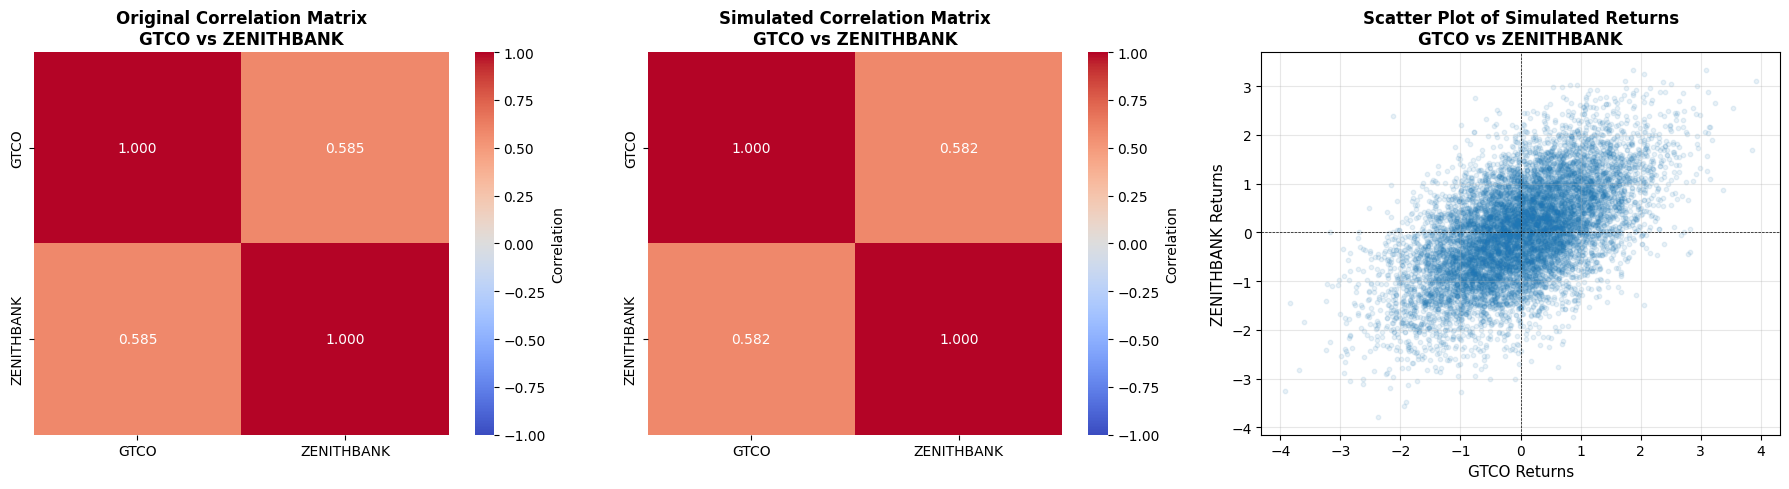


 Visualization shows the correlation structure for your assigned pair: GTCO and ZENITHBANK
   Notice how the scatter plot shape reflects the correlation coefficient of 0.585


In [76]:
np.random.seed(42)
stock1, stock2 = 'GTCO', 'ZENITHBANK'
vis_samples = generate_correlated_stock_samples(10000, df_return[['GTCO', 'ZENITHBANK']])

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original correlation heatmap
sns.heatmap(new_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[0].set_title(f'Original Correlation Matrix\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')

# Plot 2: Sample correlation heatmap
sample_corr_vis = vis_samples.corr()
sns.heatmap(sample_corr_vis, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[1].set_title(f'Simulated Correlation Matrix\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')

# Plot 3: Scatter plot
axes[2].scatter(vis_samples.iloc[:, 0], vis_samples.iloc[:, 1], alpha=0.1, s=10)
axes[2].set_xlabel(f'{stock1} Returns', fontsize=11)
axes[2].set_ylabel(f'{stock2} Returns', fontsize=11)
axes[2].set_title(f'Scatter Plot of Simulated Returns\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[2].axvline(x=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\n Visualization shows the correlation structure for your assigned pair: {stock1} and {stock2}")
print(f"   Notice how the scatter plot shape reflects the correlation coefficient of {new_corr.iloc[0, 1]:.3f}")


In [77]:
np.random.seed(42)
# Test each sample size
sample_sizes = [100, 1000, 3000, 5000, 10000, 20000]
original_corr = new_corr.iloc[0, 1]
target = 0.01

for n in sample_sizes:
    samples = generate_correlated_stock_samples(n, df_return[['GTCO', 'ZENITHBANK']])
    sample_corr = samples.corr().iloc[0, 1]
    diff = abs(original_corr - sample_corr)
    print(f"n={n}: sample_corr={round(sample_corr,4)}, diff={round(diff,4)}, within 0.01: {diff < target}")

# Find minimum sample size that achieves accuracy
for n in sample_sizes:
    samples = generate_correlated_stock_samples(n, df_return[['GTCO', 'ZENITHBANK']])
    sample_corr = samples.corr().iloc[0, 1]
    diff = abs(original_corr - sample_corr)
    if diff < target:
        print(f"\nMinimum sample size: {n}")
        break

n=100: sample_corr=0.4862, diff=0.0992, within 0.01: False
n=1000: sample_corr=0.571, diff=0.0144, within 0.01: False
n=3000: sample_corr=0.5801, diff=0.0053, within 0.01: True
n=5000: sample_corr=0.5906, diff=0.0052, within 0.01: True
n=10000: sample_corr=0.5819, diff=0.0035, within 0.01: True
n=20000: sample_corr=0.5924, diff=0.007, within 0.01: True

Minimum sample size: 1000


In [78]:
def calculate_minimum_variance_weights(simulated_returns):
    # Step 1: Calculate covariance matrix from simulated returns
    cov_matrix = df_return[['GTCO', 'ZENITHBANK']].cov()

    # Step 2: Extract individual variances and covariance
    sigma1_sq = cov_matrix.iloc[0, 0]  # variance of stock 1
    sigma2_sq = cov_matrix.iloc[1, 1]  # variance of stock 2
    sigma12   = cov_matrix.iloc[0, 1]  # covariance between stocks

    # Step 3: Apply minimum variance formula
    w1 = (sigma2_sq - sigma12) / (sigma1_sq + sigma2_sq - 2 * sigma12)
    w2 = 1 - w1

    # Step 4: Return as pandas Series with stock tickers as index
    weights = pd.Series(
        [w1, w2],
        index=simulated_returns.columns
    )

    return weights

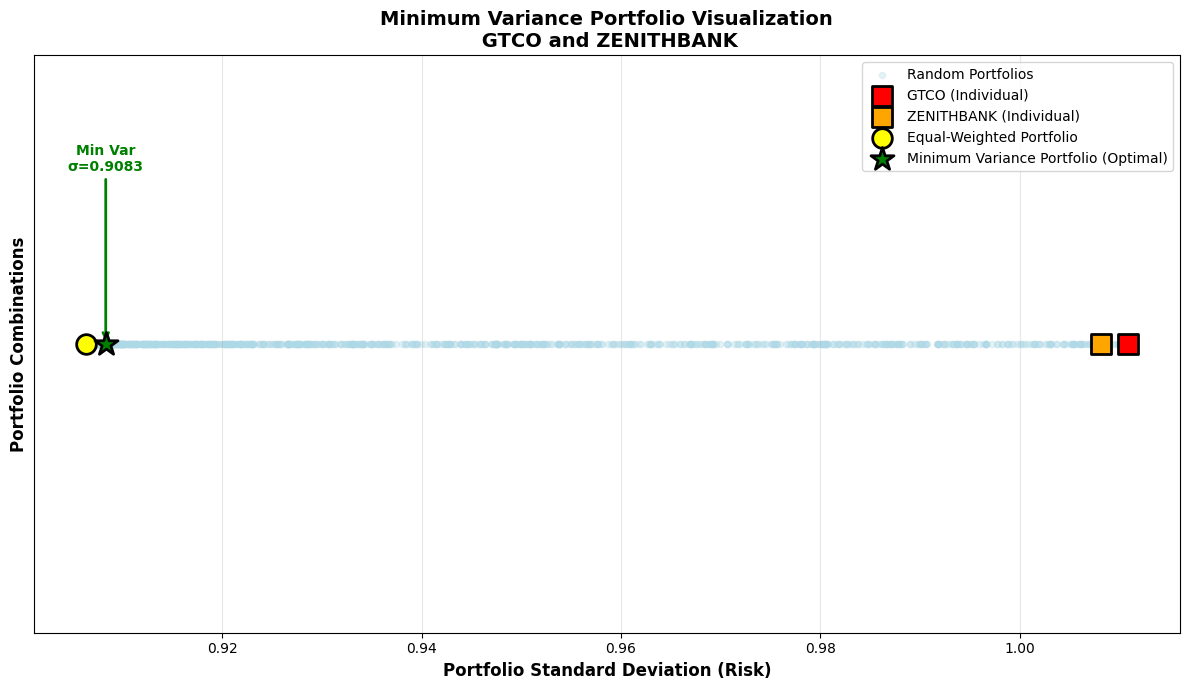


 Interpretation:
   The green star shows your optimal minimum variance portfolio.
   It has the LOWEST risk (standard deviation) among all possible
   two-stock portfolios with GTCO and ZENITHBANK.

   Notice how diversification (combining stocks) can reduce risk below
   the individual stock levels!


In [79]:
# Generate many portfolio combinations
n_portfolios = 1000
weights_array = np.random.dirichlet(np.ones(2), n_portfolios)

# Calculate covariance matrix
test_simulated_returns = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
cov_matrix = test_simulated_returns.cov()

# Calculate portfolio statistics for each combination
portfolio_returns = []
portfolio_stds = []

for weights in weights_array:
    # Portfolio variance and std dev
    port_var = weights @ cov_matrix.values @ weights
    port_std = np.sqrt(port_var)
    portfolio_stds.append(port_std)

# Get optimal weights
optimal_weights = calculate_minimum_variance_weights(test_simulated_returns)
optimal_var = optimal_weights.values @ cov_matrix.values @ optimal_weights.values
optimal_std = np.sqrt(optimal_var)

# Equal weights
equal_weights_array = np.array([0.5, 0.5])
equal_var = equal_weights_array @ cov_matrix.values @ equal_weights_array
equal_std = np.sqrt(equal_var)

# Individual stocks
stock_vars = np.diag(cov_matrix)
stock_stds = np.sqrt(stock_vars)

# Create visualization
plt.figure(figsize=(12, 7))

# Plot random portfolios
plt.scatter(portfolio_stds, [0]*len(portfolio_stds), alpha=0.3, s=20,
            label='Random Portfolios', color='lightblue')

# Plot individual stocks
plt.scatter(stock_stds[0], 0, s=200, marker='s', color='red',
            label=f'GTCO (Individual)', zorder=5, edgecolors='black', linewidth=2)
plt.scatter(stock_stds[1], 0, s=200, marker='s', color='orange',
            label=f'ZENITHBANK (Individual)', zorder=5, edgecolors='black', linewidth=2)

# Plot equal-weighted portfolio
plt.scatter(equal_std, 0, s=200, marker='o', color='yellow',
            label='Equal-Weighted Portfolio', zorder=5, edgecolors='black', linewidth=2)

# Plot optimal minimum variance portfolio
plt.scatter(optimal_std, 0, s=300, marker='*', color='green',
            label='Minimum Variance Portfolio (Optimal)', zorder=10, edgecolors='black', linewidth=2)

plt.xlabel('Portfolio Standard Deviation (Risk)', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Combinations', fontsize=12, fontweight='bold')
plt.title(f'Minimum Variance Portfolio Visualization\n GTCO and ZENITHBANK',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 0.5)
plt.yticks([])

# Add annotations
plt.annotate(f'Min Var\nσ={optimal_std:.4f}',
             xy=(optimal_std, 0), xytext=(optimal_std, 0.3),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, ha='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print(f"   The green star shows your optimal minimum variance portfolio.")
print(f"   It has the LOWEST risk (standard deviation) among all possible")
print(f"   two-stock portfolios with GTCO and ZENITHBANK.")
print(f"\n   Notice how diversification (combining stocks) can reduce risk below")
print(f"   the individual stock levels!")

In [80]:
# Use this cell to calculate your answer
# Generate samples and get optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

print(f"Optimal weights: {optimal_weights.values.round(4)}")

# Calculate ENB
ENB = 1 / np.sum(optimal_weights ** 2)
print(f"ENB = 1 / ({round(optimal_weights.iloc[0]**2, 4)} + {round(optimal_weights.iloc[1]**2, 4)})")
print(f"ENB = {round(ENB, 4)}")

Optimal weights: [0.5645 0.4355]
ENB = 1 / (0.3186 + 0.1897)
ENB = 1.9673


In [81]:
# Use this cell to calculate your answer

# Generate samples and get optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Step 1: Covariance matrix
cov_matrix = samples.cov().values

# Step 2: Weight vector
w = optimal_weights.values

# Step 3: Compute covariance matrix × weights
cov_w = cov_matrix @ w

# Step 4: First element (MCR for stock 1)
cov_w_1 = cov_w[0]

# Step 5: Portfolio standard deviation
portfolio_variance = w.T @ cov_matrix @ w
portfolio_std = np.sqrt(portfolio_variance)
print(f"Portfolio std dev: {round(portfolio_std, 6)}")

# Step 6: MCR for stock 1
MCR_1 = cov_w_1 / portfolio_std
print(f"MCR of GTCO: {round(MCR_1, 6)}")

Portfolio std dev: 0.880414
MCR of GTCO: 0.902445


In [93]:
cov_w_2 = cov_w[1]

# Step 5: Portfolio standard deviation
portfolio_variance = w.T @ cov_matrix @ w
portfolio_std = np.sqrt(portfolio_variance)
print(f"Portfolio std dev: {round(portfolio_std, 6)}")

# Step 6: MCR for stock 1
MCR_2 = cov_w_2 / portfolio_std
print(f"MCR of ZENITHBANK: {round(MCR_1, 6)}")

Portfolio std dev: 0.880414
MCR of ZENITHBANK: 0.902445


In [82]:
# FD-GCA-M2-Q9 Coding task starter code

def calculate_portfolio_var(simulated_returns, weights, confidence_levels):
    # Step 1: Convert weights to numpy array (handles both Series and ndarray)
    if isinstance(weights, pd.Series):
        w = weights.values
    else:
        w = np.array(weights)

    # Step 2: Calculate portfolio returns (weighted sum of stock returns)
    # Each row is one simulated day, multiply each stock return by its weight
    portfolio_returns = simulated_returns.values @ w

    # Step 3: Portfolio statistics
    portfolio_mean = float(np.mean(portfolio_returns))
    portfolio_std = float(np.std(portfolio_returns, ddof=1))

    # Step 4: Calculate VaR for each confidence level
    var_dict = {}
    for confidence in confidence_levels:
        # 95% VaR uses 5th percentile, 99% VaR uses 1st percentile
        percentile = (1 - confidence) * 100
        var_value = -np.percentile(portfolio_returns, percentile)
        var_dict[confidence] = float(var_value)

    # Step 5: Return results dictionary
    return {
        'portfolio_returns': portfolio_returns,
        'portfolio_mean':    portfolio_mean,
        'portfolio_std':     portfolio_std,
        'VaR':               var_dict
    }


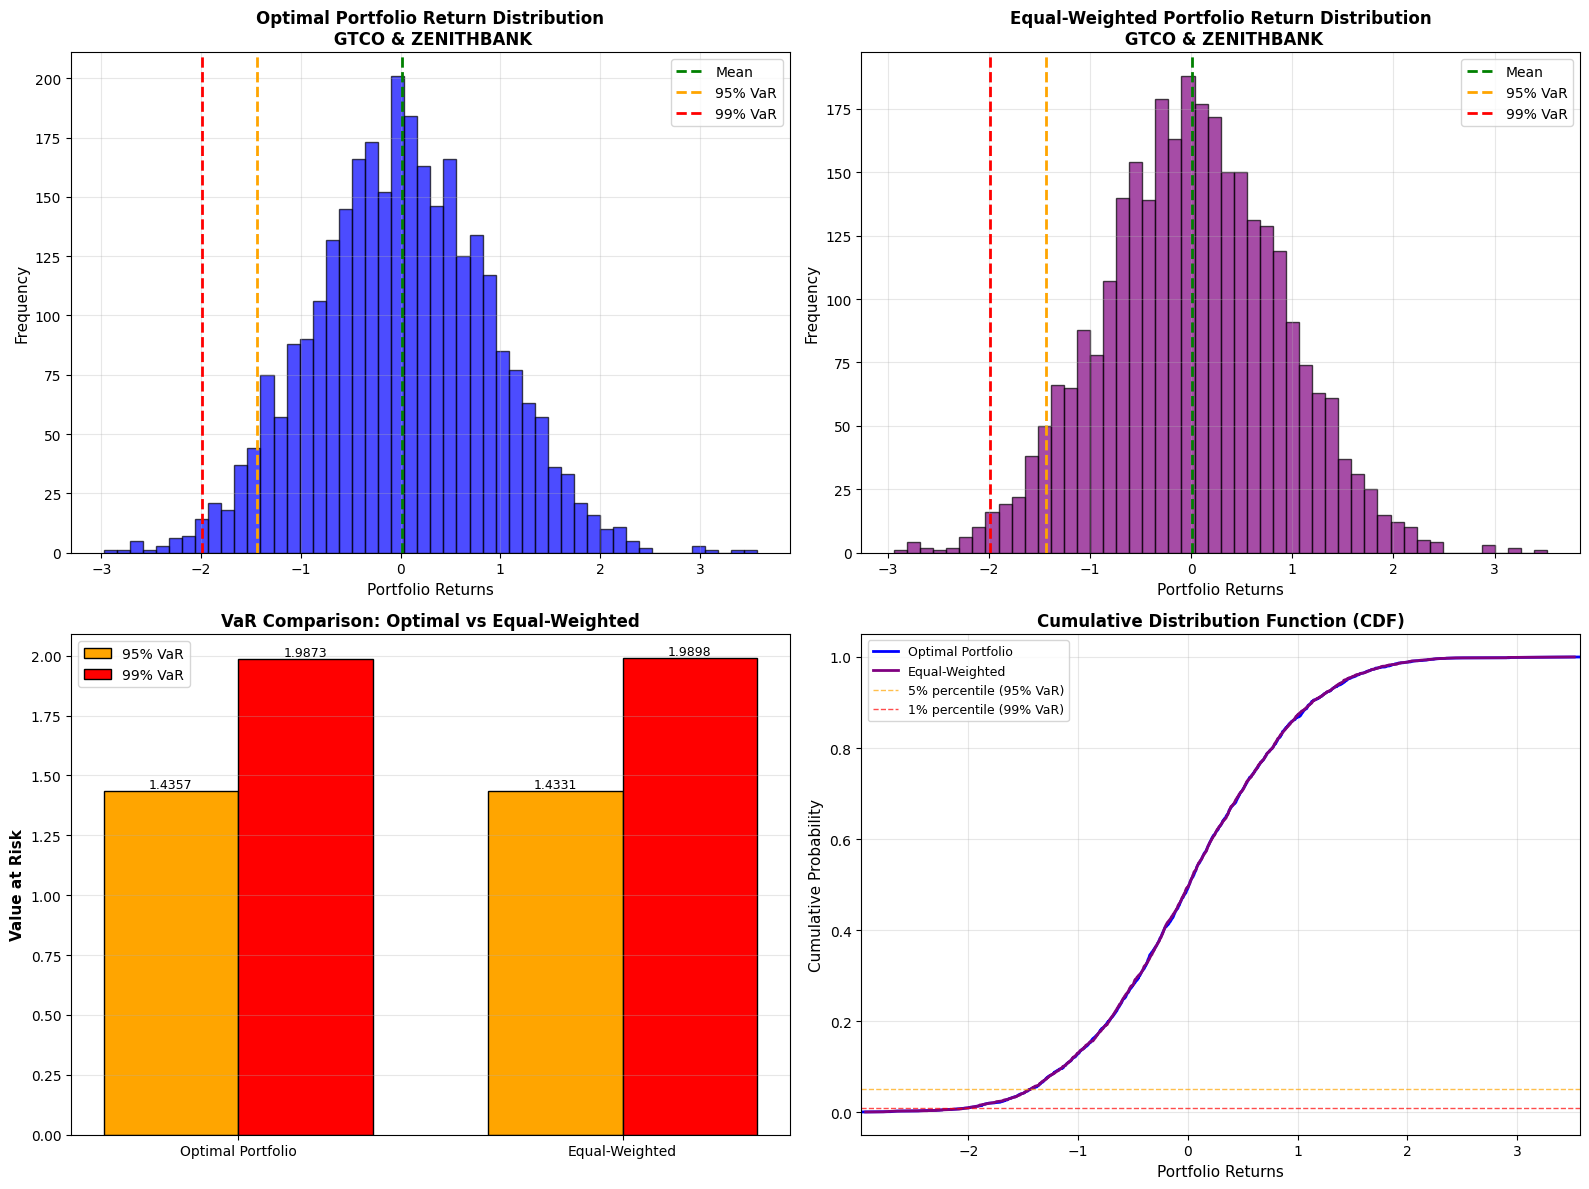


📊 COMPREHENSIVE RISK COMPARISON

🎯 OPTIMAL PORTFOLIO (Minimum Variance):
   Weights: [0.56449021 0.43550979]
   Mean Return: 0.012720
   Std Deviation: 0.880414
   95% VaR: 1.435683 (143.568%)
   99% VaR: 1.987254 (198.725%)

⚖️  EQUAL-WEIGHTED PORTFOLIO:
   Weights: [0.5 0.5]
   Mean Return: 0.009864
   Std Deviation: 0.879142
   95% VaR: 1.433057 (143.306%)
   99% VaR: 1.989814 (198.981%)

📉 RISK REDUCTION (Optimal vs Equal-Weighted):
   Volatility Reduction: -0.14%
   95% VaR Reduction: -0.18%
   99% VaR Reduction: 0.13%

💡 INTERPRETATION:
   The optimal portfolio achieves lower risk (VaR) through strategic allocation
   based on the correlation structure between the two stocks.
   This demonstrates the power of Modern Portfolio Theory and Monte Carlo
   simulation in quantitative risk management!


In [83]:
# Comprehensive Visualization of Portfolio Risk

# Generate results for visualization
np.random.seed(42)
vis_simulated_returns = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
vis_optimal_weights = calculate_minimum_variance_weights(vis_simulated_returns)
vis_equal_weights = pd.Series([0.5, 0.5], index=vis_simulated_returns.columns)

# Calculate VaR for both portfolios
optimal_var_result = calculate_portfolio_var(vis_simulated_returns, vis_optimal_weights, [0.95, 0.99])
equal_var_result = calculate_portfolio_var(vis_simulated_returns, vis_equal_weights, [0.95, 0.99])

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution of portfolio returns (Optimal)
ax1 = axes[0, 0]
ax1.hist(optimal_var_result['portfolio_returns'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(optimal_var_result['portfolio_mean'], color='green', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(-optimal_var_result['VaR'][0.95], color='orange', linestyle='--', linewidth=2, label='95% VaR')
ax1.axvline(-optimal_var_result['VaR'][0.99], color='red', linestyle='--', linewidth=2, label='99% VaR')
ax1.set_xlabel('Portfolio Returns', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title(f'Optimal Portfolio Return Distribution\n GTCO & ZENITHBANK',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of portfolio returns (Equal-weighted)
ax2 = axes[0, 1]
ax2.hist(equal_var_result['portfolio_returns'], bins=50, alpha=0.7, color='purple', edgecolor='black')
ax2.axvline(equal_var_result['portfolio_mean'], color='green', linestyle='--', linewidth=2, label='Mean')
ax2.axvline(-equal_var_result['VaR'][0.95], color='orange', linestyle='--', linewidth=2, label='95% VaR')
ax2.axvline(-equal_var_result['VaR'][0.99], color='red', linestyle='--', linewidth=2, label='99% VaR')
ax2.set_xlabel('Portfolio Returns', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title(f'Equal-Weighted Portfolio Return Distribution\n GTCO & ZENITHBANK',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: VaR Comparison
ax3 = axes[1, 0]
x_pos = np.arange(2)
var_95_values = [optimal_var_result['VaR'][0.95], equal_var_result['VaR'][0.95]]
var_99_values = [optimal_var_result['VaR'][0.99], equal_var_result['VaR'][0.99]]

width = 0.35
bars1 = ax3.bar(x_pos - width/2, var_95_values, width, label='95% VaR', color='orange', edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, var_99_values, width, label='99% VaR', color='red', edgecolor='black')

ax3.set_ylabel('Value at Risk', fontsize=11, fontweight='bold')
ax3.set_title('VaR Comparison: Optimal vs Equal-Weighted', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Optimal Portfolio', 'Equal-Weighted'], fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

# Plot 4: Cumulative Distribution Function (CDF)
ax4 = axes[1, 1]
sorted_optimal = np.sort(optimal_var_result['portfolio_returns'])
sorted_equal = np.sort(equal_var_result['portfolio_returns'])
cdf_optimal = np.arange(1, len(sorted_optimal)+1) / len(sorted_optimal)
cdf_equal = np.arange(1, len(sorted_equal)+1) / len(sorted_equal)

ax4.plot(sorted_optimal, cdf_optimal, label='Optimal Portfolio', linewidth=2, color='blue')
ax4.plot(sorted_equal, cdf_equal, label='Equal-Weighted', linewidth=2, color='purple')

# Mark VaR levels
ax4.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='5% percentile (95% VaR)')
ax4.axhline(y=0.01, color='red', linestyle='--', linewidth=1, alpha=0.7, label='1% percentile (99% VaR)')

ax4.set_xlabel('Portfolio Returns', fontsize=11)
ax4.set_ylabel('Cumulative Probability', fontsize=11)
ax4.set_title('Cumulative Distribution Function (CDF)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim([sorted_optimal[0], sorted_optimal[-1]])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("📊 COMPREHENSIVE RISK COMPARISON")
print("="*70)

print("\n🎯 OPTIMAL PORTFOLIO (Minimum Variance):")
print(f"   Weights: {vis_optimal_weights.values}")
print(f"   Mean Return: {optimal_var_result['portfolio_mean']:.6f}")
print(f"   Std Deviation: {optimal_var_result['portfolio_std']:.6f}")
print(f"   95% VaR: {optimal_var_result['VaR'][0.95]:.6f} ({optimal_var_result['VaR'][0.95]*100:.3f}%)")
print(f"   99% VaR: {optimal_var_result['VaR'][0.99]:.6f} ({optimal_var_result['VaR'][0.99]*100:.3f}%)")

print("\n⚖️  EQUAL-WEIGHTED PORTFOLIO:")
print(f"   Weights: {vis_equal_weights.values}")
print(f"   Mean Return: {equal_var_result['portfolio_mean']:.6f}")
print(f"   Std Deviation: {equal_var_result['portfolio_std']:.6f}")
print(f"   95% VaR: {equal_var_result['VaR'][0.95]:.6f} ({equal_var_result['VaR'][0.95]*100:.3f}%)")
print(f"   99% VaR: {equal_var_result['VaR'][0.99]:.6f} ({equal_var_result['VaR'][0.99]*100:.3f}%)")

print("\n📉 RISK REDUCTION (Optimal vs Equal-Weighted):")
std_reduction = ((equal_var_result['portfolio_std'] - optimal_var_result['portfolio_std']) /
                 equal_var_result['portfolio_std']) * 100
var95_reduction = ((equal_var_result['VaR'][0.95] - optimal_var_result['VaR'][0.95]) /
                   equal_var_result['VaR'][0.95]) * 100
var99_reduction = ((equal_var_result['VaR'][0.99] - optimal_var_result['VaR'][0.99]) /
                   equal_var_result['VaR'][0.99]) * 100

print(f"   Volatility Reduction: {std_reduction:.2f}%")
print(f"   95% VaR Reduction: {var95_reduction:.2f}%")
print(f"   99% VaR Reduction: {var99_reduction:.2f}%")

print("\n💡 INTERPRETATION:")
print("   The optimal portfolio achieves lower risk (VaR) through strategic allocation")
print("   based on the correlation structure between the two stocks.")
print("   This demonstrates the power of Modern Portfolio Theory and Monte Carlo")
print("   simulation in quantitative risk management!")
print("="*70)

In [84]:
# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_95 = risk_metrics['VaR'][0.95]
print(f"95% VaR: {round(var_95, 6)}")

# Expected Shortfall — average of returns BELOW the VaR threshold
threshold = -var_95
tail_returns = portfolio_returns[portfolio_returns <= threshold]
ES_95 = -np.mean(tail_returns)

print(f"Number of tail returns: {len(tail_returns)}")
print(f"95% Expected Shortfall: {round(ES_95, 6)}")

95% VaR: 1.435683
Number of tail returns: 150
95% Expected Shortfall: 1.780428


In [85]:
# Use this cell to calculate your answer

# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns and VaR
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_95 = risk_metrics['VaR'][0.95]

# Count exceedances — returns that fell BELOW the VaR threshold
exceedances = np.sum(portfolio_returns <= -var_95)
print(f"95% VaR threshold: {round(-var_95, 6)}")
print(f"Number of exceedances: {exceedances}")
print(f"Expected exceedances (5% of 3000): {int(3000 * 0.05)}")
print(f"Actual exceedance rate: {round(exceedances/3000*100, 2)}%")

95% VaR threshold: -1.435683
Number of exceedances: 150
Expected exceedances (5% of 3000): 150
Actual exceedance rate: 5.0%


In [86]:
# Use this cell to calculate your answer

# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns and 99% VaR
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_99 = risk_metrics['VaR'][0.99]

# Calculate 99% ES
threshold_99 = -var_99
tail_returns_99 = portfolio_returns[portfolio_returns <= threshold_99]
ES_99 = -np.mean(tail_returns_99)

# Calculate ES/VaR ratio
ratio = ES_99 / var_99

print(f"99% VaR: {round(var_99, 6)}")
print(f"99% ES:  {round(ES_99, 6)}")
print(f"ES/VaR ratio: {round(ratio, 4)}")

99% VaR: 1.987254
99% ES:  2.303449
ES/VaR ratio: 1.1591
